##  Movie Recommendation System with Filtering

## 1. Introduction

Recommendation engines are everywhere these days. In fact, some of the biggest brands we engage with every day are built around one, including Netflix, Amazon, Google, and Goodreads. 35 % of purchases on Amazon come from product recommendations. So, what is a recommendation engine, and how does it work?    

### The more you use, the more data accumulates, the more accurate the system would be

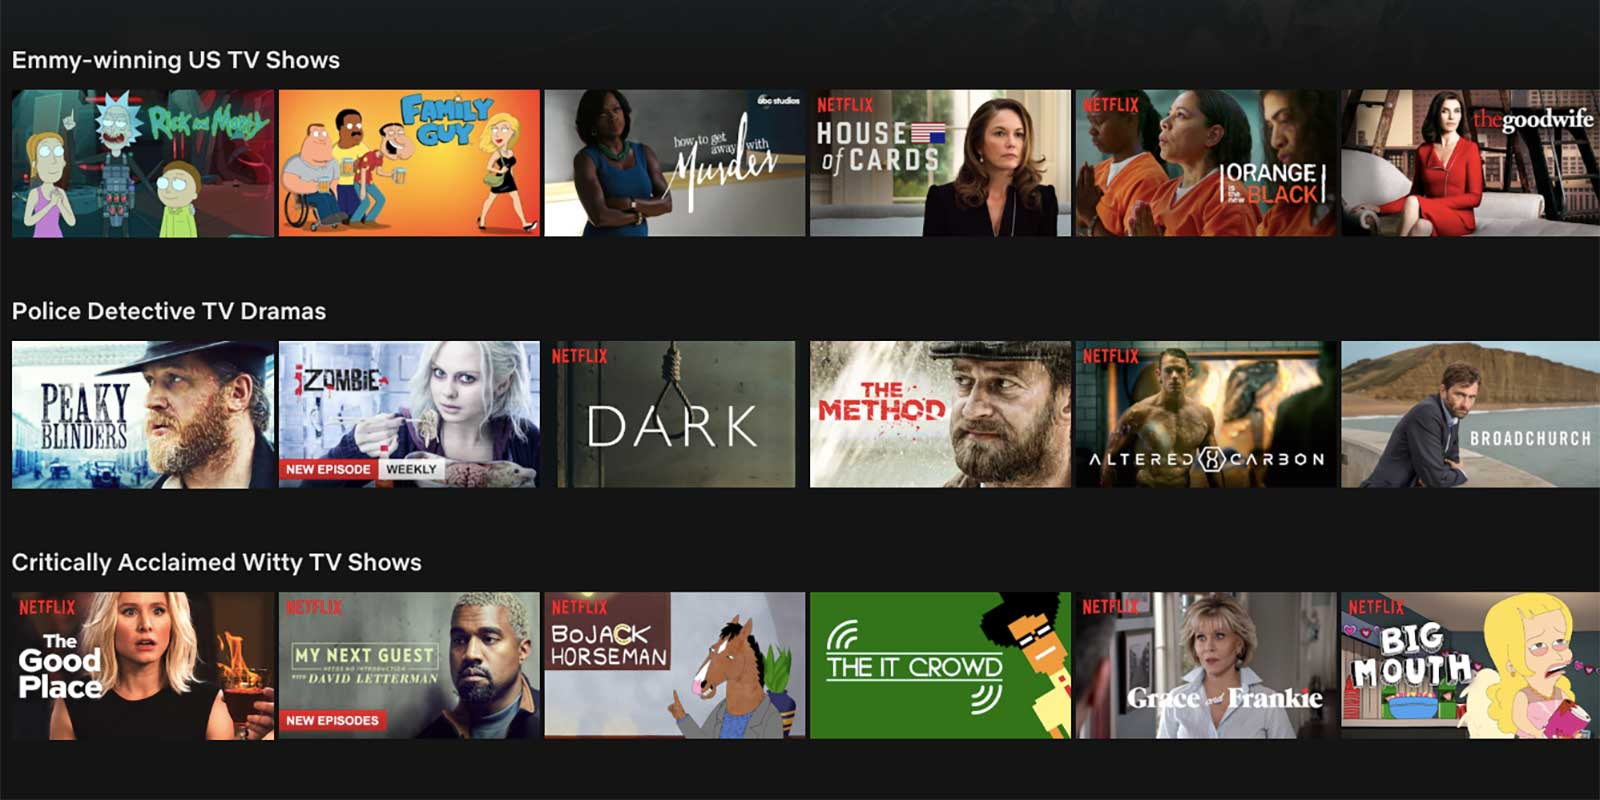

Recommender systems are often seen as a “black box”, the model created by these large companies are not very easily interpretable. The results which are generated are often recommendations for the user for things that they need / want but are unaware that they need / want it until they’ve been recommended to them.

## 2. Why do we need recommendation system?

Recommendation System belongs to the class of Information Retrieval, Data Mining and Machine Learning. Recommender systems play a major role in today's ecommerce industry. Recommender systems recommend items to users such as books, movies, videos, electronic products and many other products in general. Recommender systems help the users to get personalized recommendations, helps users to take correct decisions in their online transactions, increase sales and redefine the users web browsing experience, retain the customers, enhance their shopping experience. Information overload problem is solved by search engines, but they do not provide personalization of data. Recommendation engines provide personalization. There are different type of recommender systems such as content-based, collaborative filtering, hybrid recommender system, demographic and keyword based recommender system.(Vaidya et al., 2017)

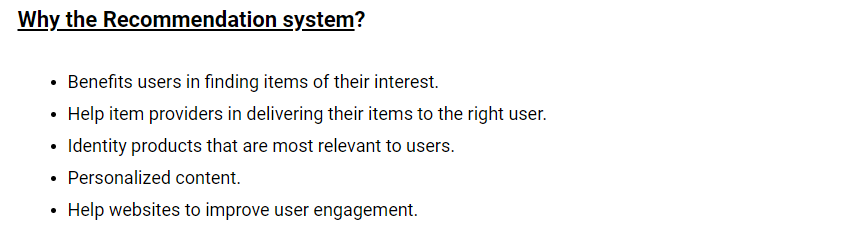

### To efficiently deal with the information overload in the era of big data

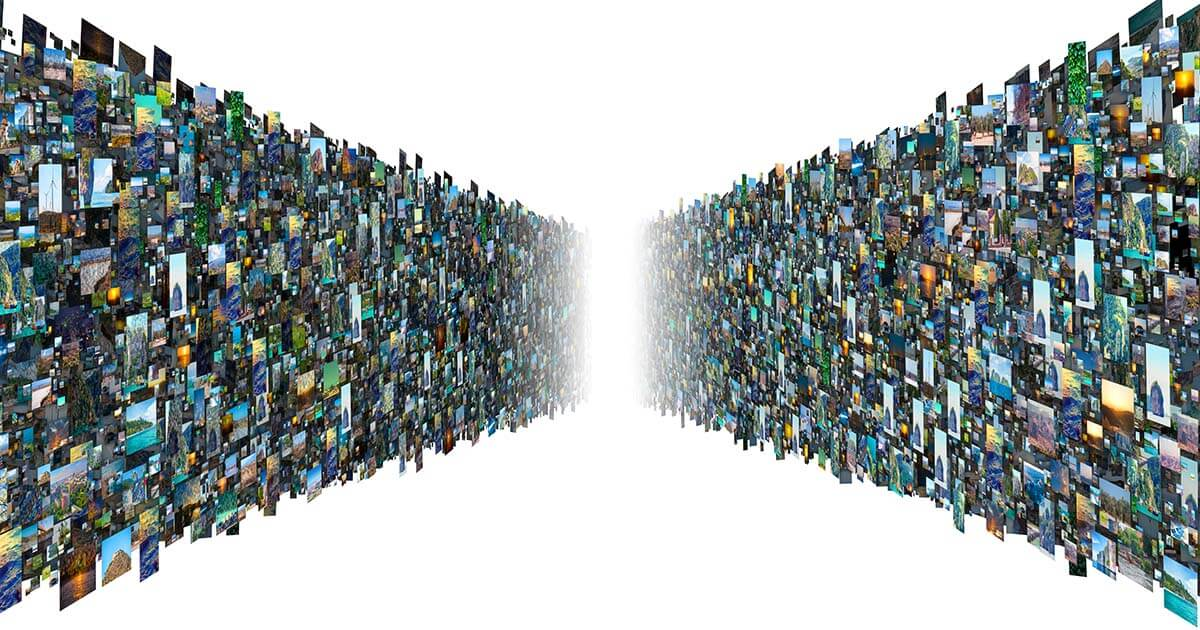

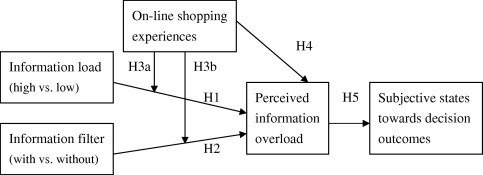(Chen et al., 2009)

1. What items did customer buy?2. What are they browsing?3. What did they click on?4. What are the rates / stars?

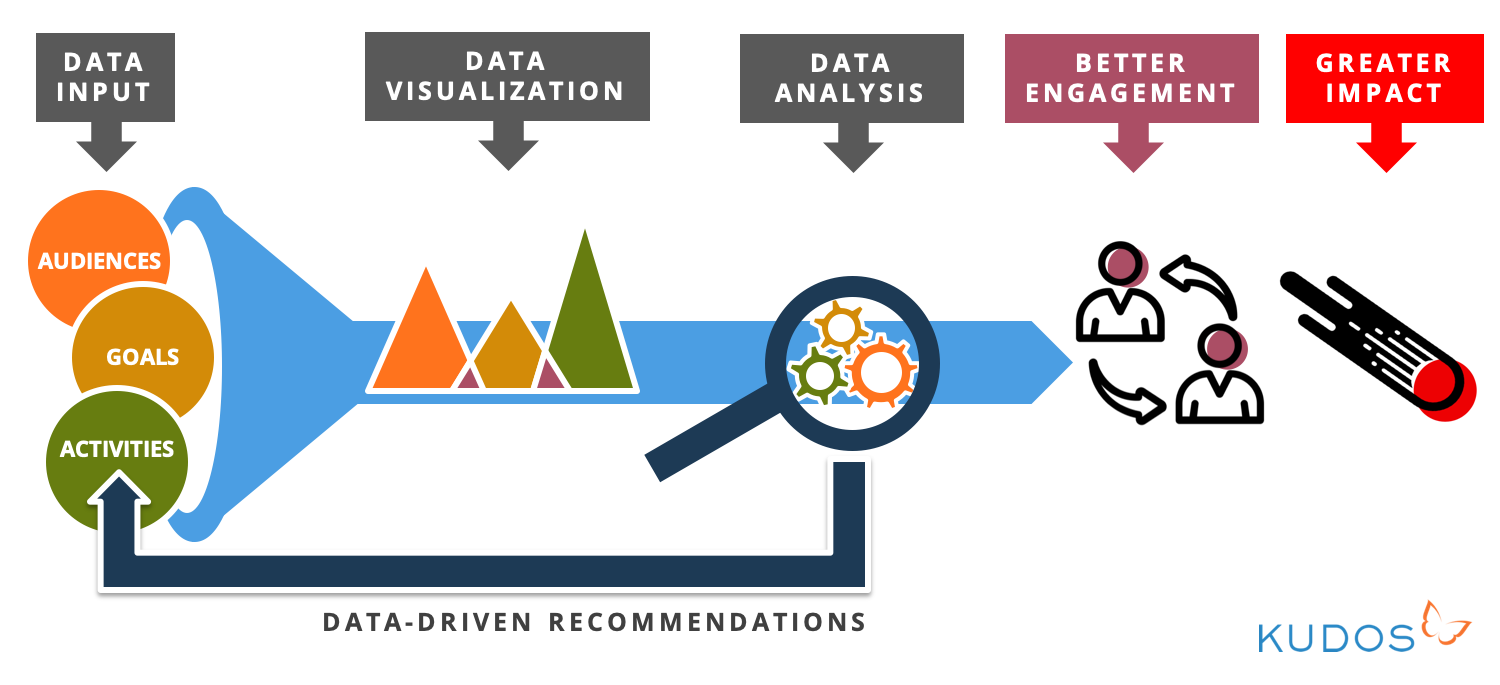

## 3. Types of Recommendation System### 1) Content based filteringContent-based filtering works on the principle that if you like a particular item, you will also like this other item. To make recommendations, algorithms use a profile of the customer’s preferences and a description of an item (genre, product type, color, word length) to work out the similarity of items using cosine and Euclidean distances.  The downside of content-based filtering is that the system is limited to recommending products or content similar to what the person is already buying or using. It can’t go beyond this to recommend other types of products or content. For example, it couldn’t recommend products beyond homeware if the customer had only brought homeware.### 2) Collaborative filtering (reflecting my neighbors)Collaborative filtering focuses on collecting and analyzing data on user behavior, activities, and preferences, to predict what a person will like, based on their similarity to other users.To plot and calculate these similarities, collaborative filtering uses a matrix style formula. An advantage of collaborative filtering is that it doesn’t need to analyze or understand the content (products, films, books). It simply picks items to recommend based on what they know about the user.### 2-1) Nearest Neibhbor (K-NN)kNN is a machine learning algorithm to find clusters of similar users based on common book ratings, and make predictions using the average rating of top-k nearest neighbors. ### 2-2) Latent Factor Latent Factor Model (LFM) is one of the most successful methods for Collaborative filtering (CF) in the recommendation system, in which both users and items are projected into a joint latent factor space. Base on matrix factorization applied usually in pattern recognition (Fang et al., 2020)

In the beginning engineers prefered content based filtering; however, Collaborative filtering recently won the netflix recommendation engineering contest.

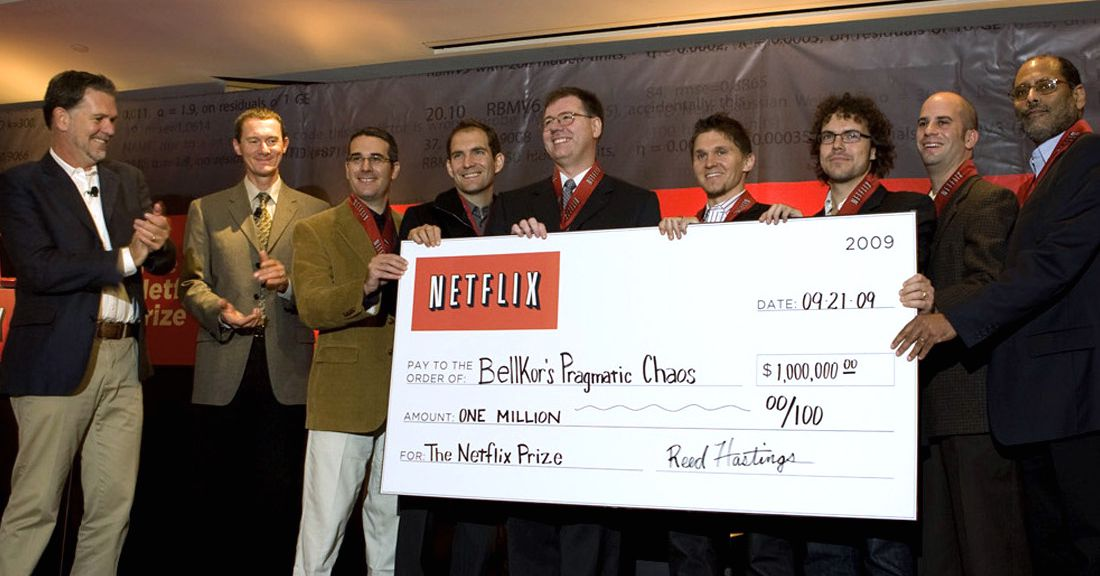

### 3) Hybrid modelA hybrid recommendation engine looks at both the meta (collaborative) data and the transactional (content-based) data. Because of this, it outperforms both.In a hybrid recommendation engine, natural language processing tags can be generated for each product or item (movie, song), and vector equations used to calculate the similarity of products. A collaborative filtering matrix can then be used to recommend items to users depending on their behaviors, activities, and preferences. Netflix is the perfect example of a hybrid recommendation engine. It takes into account both the interests of the user (collaborative) and the descriptions or features of the movie or show (content-based).  ### 4) Deep Learning

https://itnext.io/what-are-the-top-recommendation-engine-algorithms-used-nowadays-646f588ce639

The most modern recommendation engine algorithms, and the kind we use here at Crossing Minds, leverage deep learning to combine collaborative filtering and content-based models. Hybrid Deep Learning algorithms allow us to learn much finer interactions between users and items. Because they are non-linear, they are less prone to over-simplify a user tastes.Deep learning models can represent complex tastes over various range of items, even from cross-domain datasets (for instance covering both music, movies and TV shows). In Hybrid Deep Learning algorithms, users and items are modeled using both embeddings that are learnt using the collaborative filtering approach, and content-based features. Once embeddings and features are computed, the recommendations can also be served in real time.

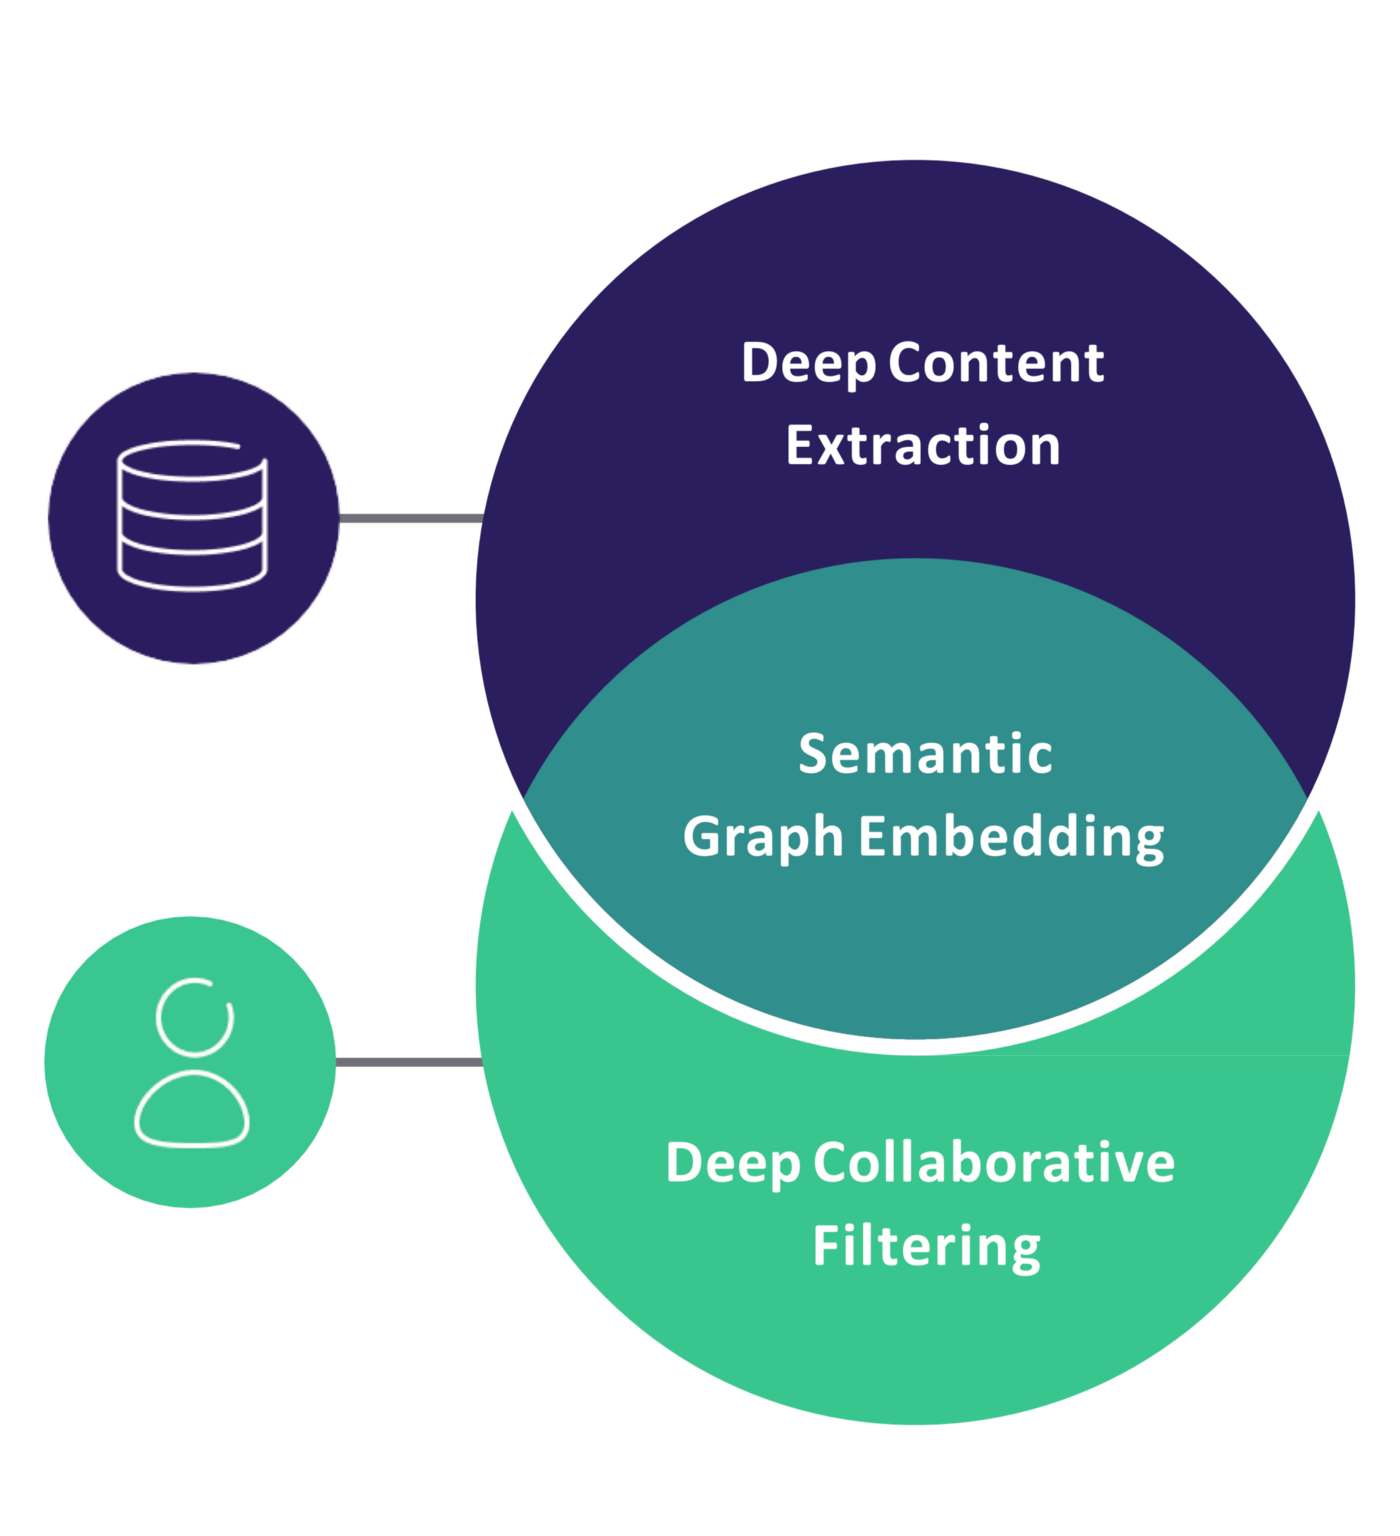

The learning schemes of such algorithms is close to traditional deep learning, that is mini-batch SGD with acceleration heuristics. But the fact that recommendation datasets are quite different from usual computer vision datasets makes it much more complex to use existing implementation and tools (for instance many optimizers in libraries like TensorFlow or PyTorch do not support sparse update of the momentum, which is a cornerstone of training deep models for recommendation). Engineers and researchers are often left to implement and train more things on their own, which requires both expert time and a lot of computing resources.Another drawback of deep learning models is that they need extensive hyper-parameter optimization. Compared to the plethora of open-source architectures in computer vision, recommendation engines have almost no well known architecture or pre-trained model.

## In this exercise we will practice both content based filtering and collaborative filtering

## Content based Filtering### Data: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata

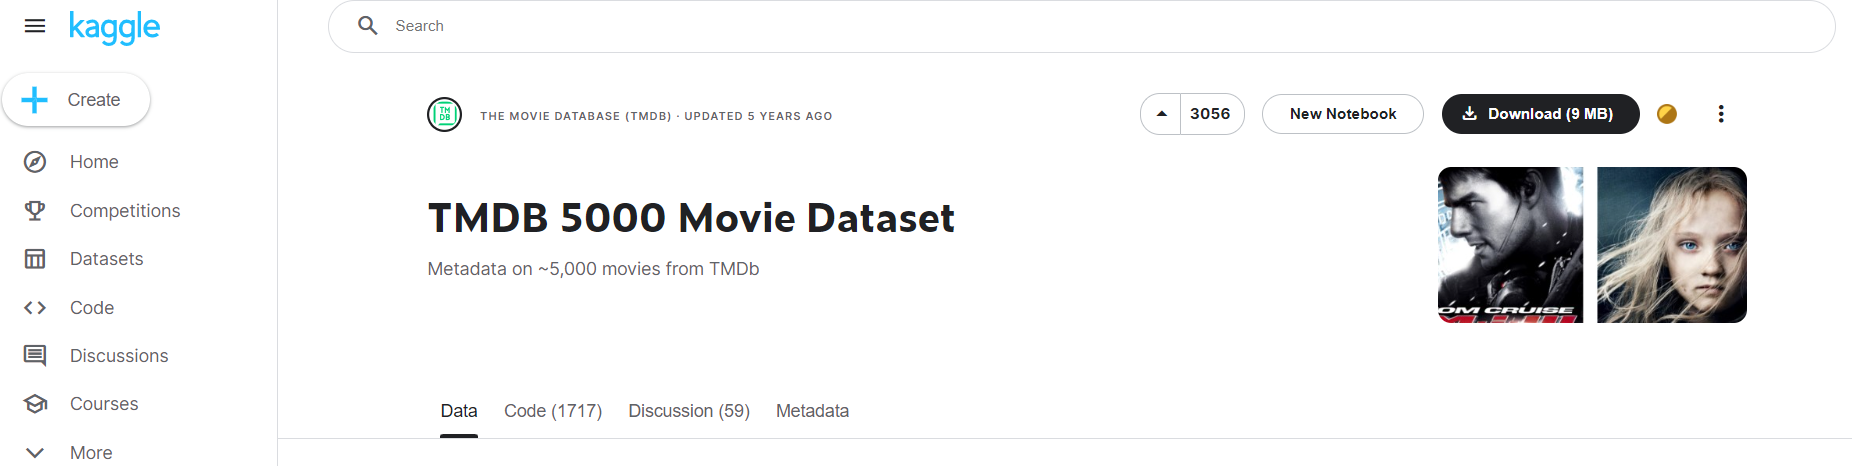

https://medium.com/web-mining-is688-spring-2021/film-recommendation-system-using-content-based-filtering-eb856c7359f3

### Content-based systems: the recommendations are based on the description of the products

In [14]:
# Source: https://www.kaggle.com/code/elahehgolrokh/tmdb-movie-data-cleaning-and-eda 
import json
import pandas as pd

def load_tmdb_movies(path):
    df = pd.read_csv(path)
    df['release_date'] = pd.to_datetime(df['release_date']).apply(lambda x: x.date())
    json_columns = ['genres', 'keywords', 'production_countries', 'production_companies', 'spoken_languages']
    for column in json_columns:
        df[column] = df[column].apply(json.loads)
    return df

def load_tmdb_credits(path):
    df = pd.read_csv(path)
    json_columns = ['cast', 'crew']
    for column in json_columns:
        df[column] = df[column].apply(json.loads)
    return df

In [15]:
import numpy as np
import math, nltk, warnings
from nltk.corpus import wordnet
from sklearn import linear_model
from sklearn.neighbors import NearestNeighbors

pd.options.display.max_columns = 50

credits_path = '/kaggle/input/tmdb-movie-metadata/tmdb_5000_credits.csv' # your path here
movies_path = '/kaggle/input/tmdb-movie-metadata/tmdb_5000_movies.csv' # your path here
credits = load_tmdb_credits(credits_path) 
movies = load_tmdb_movies(movies_path) 

In [16]:
df = pd.merge(movies, credits, left_on='id', right_on='movie_id')
print(df.shape)
df.head()

(4803, 24)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title_x,vote_average,vote_count,movie_id,title_y,cast,crew
0,237000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",http://www.avatarmovie.com/,19995,"[{'id': 1463, 'name': 'culture clash'}, {'id':...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{'name': 'Ingenious Film Partners', 'id': 289...","[{'iso_3166_1': 'US', 'name': 'United States o...",2009-12-10,2787965087,162.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,19995,Avatar,"[{'cast_id': 242, 'character': 'Jake Sully', '...","[{'credit_id': '52fe48009251416c750aca23', 'de..."
1,300000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",http://disney.go.com/disneypictures/pirates/,285,"[{'id': 270, 'name': 'ocean'}, {'id': 726, 'na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{'name': 'Walt Disney Pictures', 'id': 2}, {'...","[{'iso_3166_1': 'US', 'name': 'United States o...",2007-05-19,961000000,169.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,285,Pirates of the Caribbean: At World's End,"[{'cast_id': 4, 'character': 'Captain Jack Spa...","[{'credit_id': '52fe4232c3a36847f800b579', 'de..."
2,245000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{'id': 470, 'name': 'spy'}, {'id': 818, 'name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{'name': 'Columbia Pictures', 'id': 5}, {'nam...","[{'iso_3166_1': 'GB', 'name': 'United Kingdom'...",2015-10-26,880674609,148.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,A Plan No One Escapes,Spectre,6.3,4466,206647,Spectre,"[{'cast_id': 1, 'character': 'James Bond', 'cr...","[{'credit_id': '54805967c3a36829b5002c41', 'de..."
3,250000000,"[{'id': 28, 'name': 'Action'}, {'id': 80, 'nam...",http://www.thedarkknightrises.com/,49026,"[{'id': 849, 'name': 'dc comics'}, {'id': 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{'name': 'Legendary Pictures', 'id': 923}, {'...","[{'iso_3166_1': 'US', 'name': 'United States o...",2012-07-16,1084939099,165.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,49026,The Dark Knight Rises,"[{'cast_id': 2, 'character': 'Bruce Wayne / Ba...","[{'credit_id': '52fe4781c3a36847f81398c3', 'de..."
4,260000000,"[{'id': 28, 'name': 'Action'}, {'id': 12, 'nam...",http://movies.disney.com/john-carter,49529,"[{'id': 818, 'name': 'based on novel'}, {'id':...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{'name': 'Walt Disney Pictures', 'id': 2}]","[{'iso_3166_1': 'US', 'name': 'United States o...",2012-03-07,284139100,132.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,49529,John Carter,"[{'cast_id': 5, 'character': 'John Carter', 'c...","[{'credit_id': '52fe479ac3a36847f813eaa3', 'de..."


In [17]:
# Source: https://www.kaggle.com/code/elahehgolrokh/tmdb-movie-data-cleaning-and-eda 
# Columns that existed in the IMDB version of the dataset and are gone.
LOST_COLUMNS = [
    'actor_1_facebook_likes',
    'actor_2_facebook_likes',
    'actor_3_facebook_likes',
    'aspect_ratio',
    'cast_total_facebook_likes',
    'color',
    'content_rating',
    'director_facebook_likes',
    'facenumber_in_poster',
    'movie_facebook_likes',
    'movie_imdb_link',
    'num_critic_for_reviews',
    'num_user_for_reviews']
#____________________________________
# Columns in TMDb that had direct equivalents in the IMDB version.
# These columns can be used with old kernels just by changing the names
TMDB_TO_IMDB_SIMPLE_EQUIVALENCIES = {
    'budget': 'budget',
    'genres': 'genres',
    'revenue': 'gross',
    'title': 'movie_title',
    'runtime': 'duration',
    'original_language': 'language',
    'keywords': 'plot_keywords',
    'vote_count': 'num_voted_users'}
#_____________________________________________________
IMDB_COLUMNS_TO_REMAP = {'imdb_score': 'vote_average'}
#_____________________________________________________
def safe_access(container, index_values):
    """return missing value rather than an error upon indexing/key failure"""
    result = container
    try:
        for idx in index_values:
            result = result[idx]
        return result
    except IndexError or KeyError:
        return np.nan
#_____________________________________________________
def get_director(crew_data):
    directors = [x['name'] for x in crew_data if x['job'] == 'Director']
    return safe_access(directors, [0])
#_____________________________________________________
def pipe_flatten_names(keywords):
    return '|'.join([x['name'] for x in keywords])
#_____________________________________________________
def convert_to_original_format(movies, credits):
    """
    Converts TMDb data to make it as compatible as possible with kernels
    built on the original version of the data
    """
    tmdb_movies = movies.copy()
    tmdb_movies.rename(columns=TMDB_TO_IMDB_SIMPLE_EQUIVALENCIES, inplace=True)
    tmdb_movies['title_year'] = pd.to_datetime(tmdb_movies['release_date']).apply(lambda x: x.year)
    # I'm assuming that the first production country is equivalent, but have not been able to validate this
    tmdb_movies['country'] = tmdb_movies['production_countries'].apply(lambda x: safe_access(x, [0, 'name']))
    tmdb_movies['language'] = tmdb_movies['spoken_languages'].apply(lambda x: safe_access(x, [0, 'name']))
    tmdb_movies['director_name'] = credits['crew'].apply(get_director)
    tmdb_movies['actor_1_name'] = credits['cast'].apply(lambda x: safe_access(x, [1, 'name']))
    tmdb_movies['actor_2_name'] = credits['cast'].apply(lambda x: safe_access(x, [2, 'name']))
    tmdb_movies['actor_3_name'] = credits['cast'].apply(lambda x: safe_access(x, [3, 'name']))
    tmdb_movies['genres'] = tmdb_movies['genres'].apply(pipe_flatten_names)
    tmdb_movies['plot_keywords'] = tmdb_movies['plot_keywords'].apply(pipe_flatten_names)
    tmdb_movies['production_companies'] = tmdb_movies['production_companies'].apply(pipe_flatten_names)
    tmdb_movies['production_countries'] = tmdb_movies['production_countries'].apply(pipe_flatten_names)
    return tmdb_movies

In [18]:
df_initial = convert_to_original_format(movies, credits)
print('Shape:',df_initial.shape)

tab_info=pd.DataFrame(df_initial.dtypes).T.rename(index={0:'column type'})
tab_info = pd.concat([tab_info, pd.DataFrame(df_initial.isnull().sum()).T.rename(index={0:'null values'})], ignore_index=True)
tab_info = pd.concat([tab_info, pd.DataFrame(df_initial.isnull().sum()/df_initial.shape[0]*100).T.
                         rename(index={0:'null values (%)'})], ignore_index=True)
df_initial[:5]

Shape: (4803, 26)


,budget,genres,homepage,id,plot_keywords,language,original_title,overview,popularity,production_companies,production_countries,release_date,gross,duration,spoken_languages,status,tagline,movie_title,vote_average,num_voted_users,title_year,country,director_name,actor_1_name,actor_2_name,actor_3_name
0,237000000,Action|Adventure|Fantasy|Science Fiction,http://www.avatarmovie.com/,19995,culture clash|future|space war|space colony|so...,English,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,Ingenious Film Partners|Twentieth Century Fox ...,United States of America|United Kingdom,2009-12-10,2787965087,162.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,2009.0,United States of America,James Cameron,Zoe Saldana,Sigourney Weaver,Stephen Lang
1,300000000,Adventure|Fantasy|Action,http://disney.go.com/disneypictures/pirates/,285,ocean|drug abuse|exotic island|east india trad...,English,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,Walt Disney Pictures|Jerry Bruckheimer Films|S...,United States of America,2007-05-19,961000000,169.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,2007.0,United States of America,Gore Verbinski,Orlando Bloom,Keira Knightley,Stellan Skarsgård
2,245000000,Action|Adventure|Crime,http://www.sonypictures.com/movies/spectre/,206647,spy|based on novel|secret agent|sequel|mi6|bri...,Français,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,Columbia Pictures|Danjaq|B24,United Kingdom|United States of America,2015-10-26,880674609,148.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,A Plan No One Escapes,Spectre,6.3,4466,2015.0,United Kingdom,Sam Mendes,Christoph Waltz,Léa Seydoux,Ralph Fiennes
3,250000000,Action|Crime|Drama|Thriller,http://www.thedarkknightrises.com/,49026,dc comics|crime fighter|terrorist|secret ident...,English,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,Legendary Pictures|Warner Bros.|DC Entertainme...,United States of America,2012-07-16,1084939099,165.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,2012.0,United States of America,Christopher Nolan,Michael Caine,Gary Oldman,Anne Hathaway
4,260000000,Action|Adventure|Science Fiction,http://movies.disney.com/john-carter,49529,based on novel|mars|medallion|space travel|pri...,English,John Carter,"John Carter is a war-weary, former military ca...",43.926995,Walt Disney Pictures,United States of America,2012-03-07,284139100,132.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,2012.0,United States of America,Andrew Stanton,Lynn Collins,Samantha Morton,Willem Dafoe


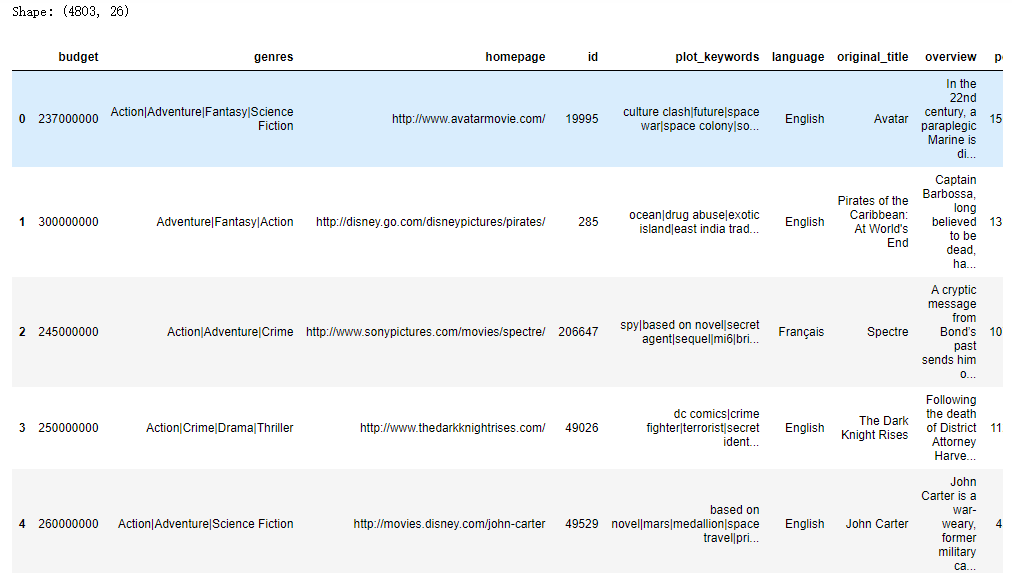

## Extract KEYWORD
Keywords will play an important role in the functioning of the system. Indeed, recommendations will be based on similarity between films and to gauge such similarities, I will look for films described by the same keywords.To develop the recommendation system, I plan to make an extensive use of the keywords that describe the films. Indeed, a basic assumption is that films described by similar keywords should have similar contents. Hence, I plan to have a close look at the way keywords are defined and as a first step, I quickly characterize what’s already in there. To do so, I first list the keywords which are in the dataset:

In [31]:
# Source: https://www.kaggle.com/code/elahehgolrokh/tmdb-movie-data-cleaning-and-eda 
def count_word(df, ref_col, liste):
    keyword_count = dict()
    for s in liste: keyword_count[s] = 0
    for liste_keywords in df[ref_col].str.split('|'):        
        if type(liste_keywords) == float and pd.isnull(liste_keywords): continue        
        for s in [s for s in liste_keywords if s in liste]: 
            if pd.notnull(s): keyword_count[s] += 1
    keyword_occurences = []
    for k,v in keyword_count.items():
        keyword_occurences.append([k,v])
    keyword_occurences.sort(key = lambda x:x[1], reverse = True)
    return keyword_occurences, keyword_count

keywords = set()
for s in df_initial['plot_keywords'].values:
  if not pd.isnull(s):
    s = s.split('|')
    keywords = keywords.union(set(s))
keywords.remove('')
print(len(keywords))


keyword_occurences, dum = count_word(df_initial, 'plot_keywords', keywords)
keyword_occurences[:5]

9813


[['woman director', 324],
 ['independent film', 318],
 ['duringcreditsstinger', 307],
 ['based on novel', 197],
 ['murder', 189]]

At this stage, the list of keywords has been created and we know the number of times each of them appear in the dataset. In fact, this list can be used to have a feeling of the content of the most popular movies.

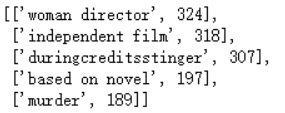

### Basic functioning of the system order to build the recommendation system, I will basically proceed in two steps:1. determine N films with a content similar to the entry provided by the user2. select the 5 most popular films among these N films

### Similarity When building the system, the first step thus consists in defining a criteria that would tell us how close two films are. To do so, I start from the description of the film that was selected by the user: from it, I get the director name, the names of the actors and a few keywords. I then build a matrix where each row corresponds to a film of the database and where the columns correspond to the previous quantities (director + actors + keywords) plus the k genres

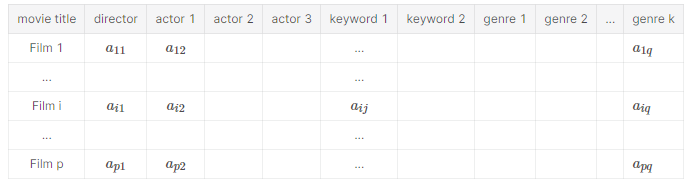

In this matrix, the aij coefficients take either the value 0 or 1 depending on the correspondance between the significance of column j and the content of film i. For exemple, if “keyword 1” is in film i, we will have aij = 1 and 0 otherwise. Once this matrix has been defined, we determine the distance between two films according to:

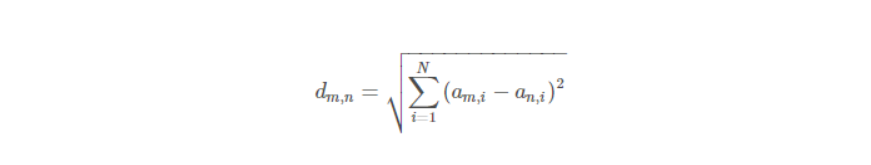

At this stage, we just have to select the N films which are the closest from the entry selected by the user.

### Cosine Similarity#### Calculate vector of each keyword and do feature vectorization n times#### Machine learning requires numeric digits while texts like keywords should be given numeric digits (Feature Vectorization)

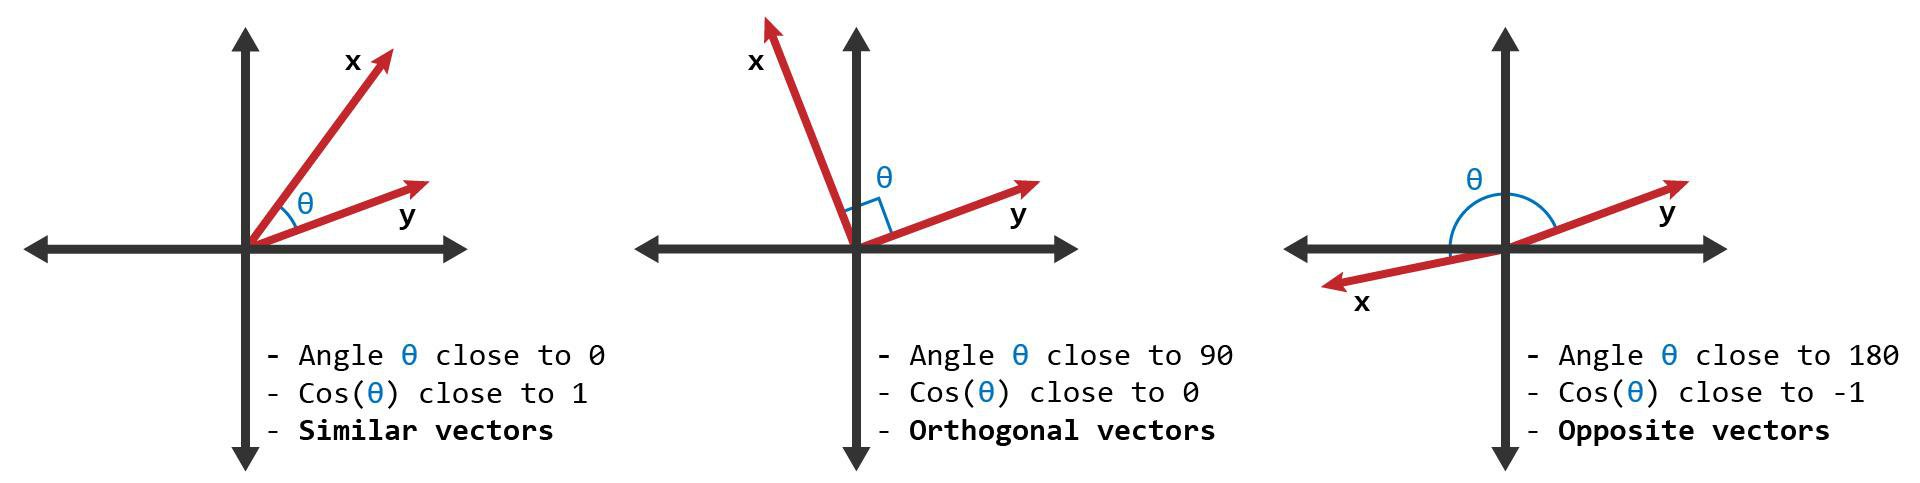

### According to similarities between entries, we get a list of N films. At this stage, I select 5 films from this list and I give a score for every entry.the score the number of votes the entry received the year of release. The two first criteria will be a direct measure of the popularity of the various entries in sets. For the third criterium, I introduce the release year since the database spans films from the early XXth century up to now. I assume that people’s favorite films will be most of the time from the same epoch.Then, I calculate the score according to the formula:

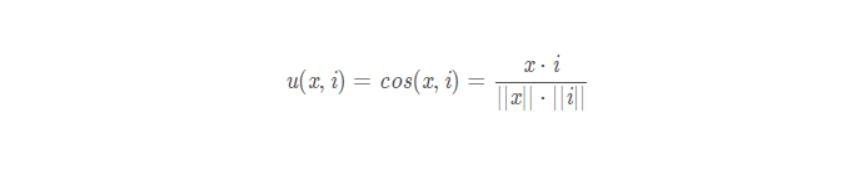

For votes, I get the maximum number of votes among the N films. For years, I center the formula on the title year of the film selected by the user. With this formula, I put more weight to the entries with a large number of votes and to the films whose release year is close to the title selected by the user. Function collecting some variables content: the entry_variables() function returns the values taken by the variables ‘director_name’, ‘actor_N_name’ (N in [1:3]) for the film selected by the user.

In [32]:
def entry_variables(df, id_entry): 
    col_labels = []    
    if pd.notnull(df['director_name'].iloc[id_entry]):
        for s in df['director_name'].iloc[id_entry].split('|'):
            col_labels.append(s)
            
    for i in range(3):
        column = 'actor_NUM_name'.replace('NUM', str(i+1))
        if pd.notnull(df[column].iloc[id_entry]):
            for s in df[column].iloc[id_entry].split('|'):
                col_labels.append(s)
                
    if pd.notnull(df['plot_keywords'].iloc[id_entry]):
        for s in df['plot_keywords'].iloc[id_entry].split('|'):
            col_labels.append(s)
    return col_labels

Function giving marks to films: the critere_selection() function gives a mark to a film depending on its movie rating score, the title year and the number of users who have voted for this film.

In [33]:
def critere_selection(title_main, max_users, annee_ref, titre, annee, imdb_score, votes):    
    if pd.notnull(annee_ref):
        facteur_1 = gaussian_filter(annee_ref, annee, 20)
    else:
        facteur_1 = 1        

    sigma = max_users * 1.0

    if pd.notnull(votes):
        facteur_2 = gaussian_filter(votes, max_users, sigma)
    else:
        facteur_2 = 0
        
    if sequel(title_main, titre):
        note = 0
    else:
        note = imdb_score**2 * facteur_1 * facteur_2
    
    return note

## Making meaningful recommendations

In [ ]:
# students may write their own find_similarities function based on cosine-similarity as practice
selection = dict()
for i in range(0, 20, 3):
    selection[i] = find_similarities(df, i, del_sequels = True, verbose = True)

## 5. Limitation: While building the recommendation system, we are quickly faced to a big issue: the existence of sequels make that some recommendations may seem quite dumb. As an exemple, somebody who enjoyed “Pirates of the Caribbean: Dead Man’s Chest” would probably not like to be adviced to watch this:

The origin of that issue is quite easily understood: many blockbusters have sequels that share the same director, actors and keywords. Most of the time, the fact that sequels exist mean that it was a “fair” box-office success, which is a synonym of a good rating score. Well, I would personnaly not make that kind of recommendations to a friend.

I personally think the results are pretty good. All the movies at the top are serious and mindful movies just like “Avatar” itself. All the movies in the top 5 , therefore I think the result are superhero or animation movies which are ideal for kids as is the input movie “Tangled”, in this case, is also good. Our model works quite well- a movie recommendation system based on user behavior.

## 6. Practice2: Collaborative Filtering

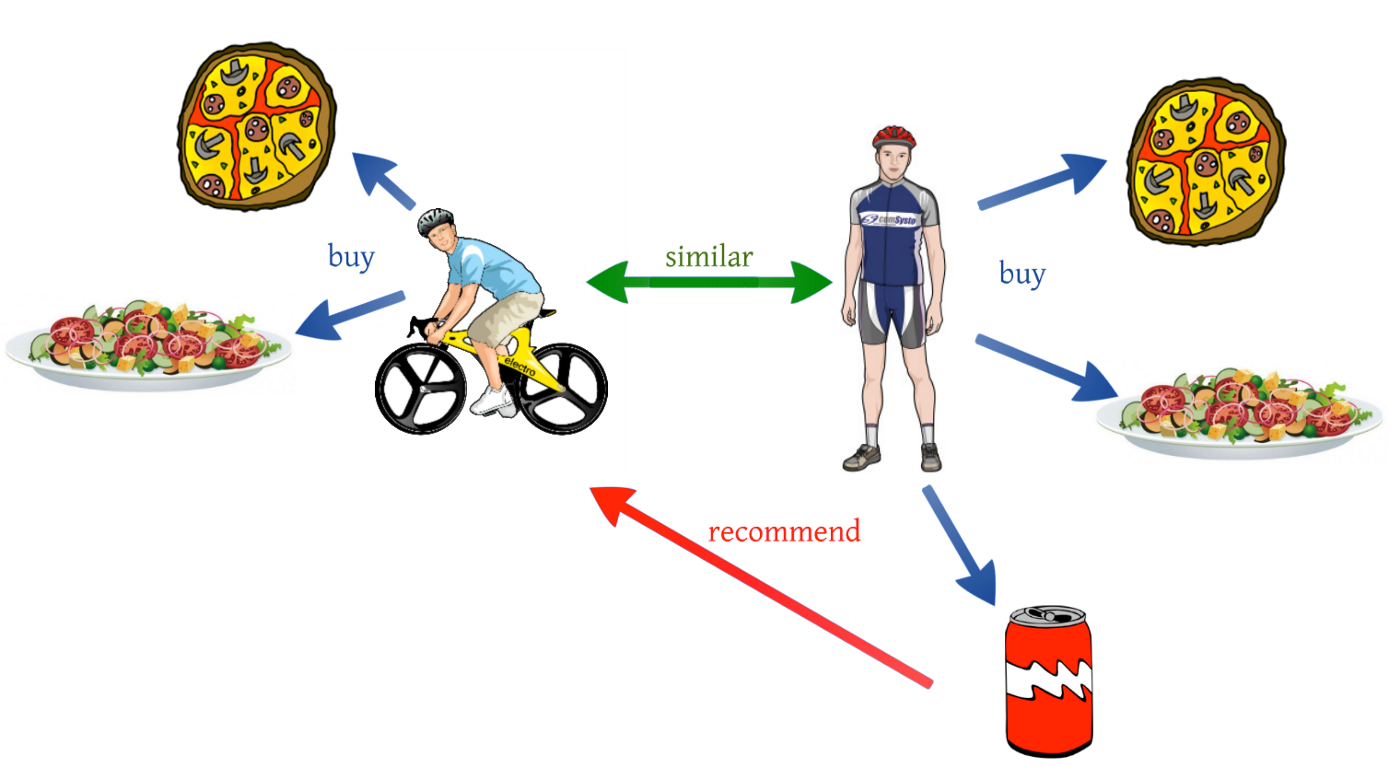

Data: https://grouplens.org/datasets/movielens/latest/

Keras Code Examples: https://keras.io/examples/structured_data/collaborative_filtering_movielens/

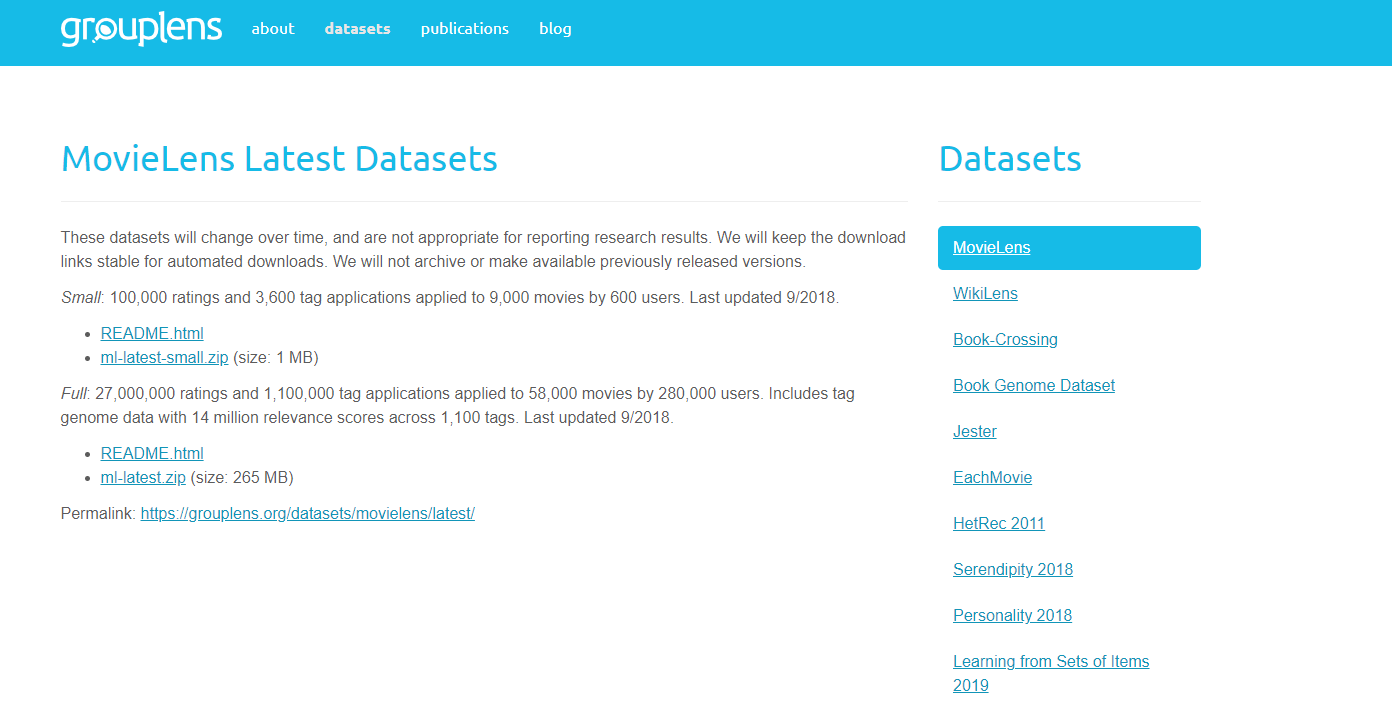

The MovieLens ratings dataset lists the ratings given by a set of users to a set of movies. Our goal is to be able to predict ratings for movies a user has not yet watched. The movies with the highest predicted ratings can then be recommended to the user.

The steps in the model are as follows:1. Map user ID to a "user vector" via an embedding matrix2. Map movie ID to a "movie vector" via an embedding matrix3. Compute the dot product between the user vector and movie vector, to obtain the a match score between the user and the movie (predicted rating).4. Train the embeddings via gradient descent using all known user-movie pairs.

In [ ]:
import pandas as pdimport numpy as npfrom zipfile import ZipFileimport tensorflow as tffrom tensorflow import kerasfrom tensorflow.keras import layersfrom pathlib import Pathimport matplotlib.pyplot as plt

## First, load the data and apply preprocessing

In [ ]:
# Download the actual data from http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"# Use the ratings.csv filemovielens_data_file_url = (    "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip")movielens_zipped_file = keras.utils.get_file(    "ml-latest-small.zip", movielens_data_file_url, extract=False)keras_datasets_path = Path(movielens_zipped_file).parents[0]movielens_dir = keras_datasets_path / "ml-latest-small"# Only extract the data the first time the script is run.if not movielens_dir.exists():    with ZipFile(movielens_zipped_file, "r") as zip:        # Extract files        print("Extracting all the files now...")        zip.extractall(path=keras_datasets_path)        print("Done!")ratings_file = movielens_dir / "ratings.csv"df = pd.read_csv(ratings_file)

need to perform some preprocessing to encode users and movies as integer indices.

In [ ]:
user_ids = df["userId"].unique().tolist()user2user_encoded = {x: i for i, x in enumerate(user_ids)}userencoded2user = {i: x for i, x in enumerate(user_ids)}movie_ids = df["movieId"].unique().tolist()movie2movie_encoded = {x: i for i, x in enumerate(movie_ids)}movie_encoded2movie = {i: x for i, x in enumerate(movie_ids)}df["user"] = df["userId"].map(user2user_encoded)df["movie"] = df["movieId"].map(movie2movie_encoded)num_users = len(user2user_encoded)num_movies = len(movie_encoded2movie)df["rating"] = df["rating"].values.astype(np.float32)# min and max ratings will be used to normalize the ratings latermin_rating = min(df["rating"])max_rating = max(df["rating"])print(    "Number of users: {}, Number of Movies: {}, Min rating: {}, Max rating: {}".format(        num_users, num_movies, min_rating, max_rating    ))

Number of users: 610, Number of Movies: 9724, Min rating: 0.5, Max rating: 5.0

### Prepare training and validation data

In [ ]:
df = df.sample(frac=1, random_state=42)x = df[["user", "movie"]].values# Normalize the targets between 0 and 1. Makes it easy to train.y = df["rating"].apply(lambda x: (x - min_rating) / (max_rating - min_rating)).values# Assuming training on 90% of the data and validating on 10%.train_indices = int(0.9 * df.shape[0])x_train, x_val, y_train, y_val = (    x[:train_indices],    x[train_indices:],    y[:train_indices],    y[train_indices:],)

### Create the modelWe embed both users and movies in to 50-dimensional vectors.The model computes a match score between user and movie embeddings via a dot product, and adds a per-movie and per-user bias. The match score is scaled to the [0, 1] interval via a sigmoid (since our ratings are normalized to this range).

In [ ]:
EMBEDDING_SIZE = 50class RecommenderNet(keras.Model):    def __init__(self, num_users, num_movies, embedding_size, **kwargs):        super(RecommenderNet, self).__init__(**kwargs)        self.num_users = num_users        self.num_movies = num_movies        self.embedding_size = embedding_size        self.user_embedding = layers.Embedding(            num_users,            embedding_size,            embeddings_initializer="he_normal",            embeddings_regularizer=keras.regularizers.l2(1e-6),        )        self.user_bias = layers.Embedding(num_users, 1)        self.movie_embedding = layers.Embedding(            num_movies,            embedding_size,            embeddings_initializer="he_normal",            embeddings_regularizer=keras.regularizers.l2(1e-6),        )        self.movie_bias = layers.Embedding(num_movies, 1)    def call(self, inputs):        user_vector = self.user_embedding(inputs[:, 0])        user_bias = self.user_bias(inputs[:, 0])        movie_vector = self.movie_embedding(inputs[:, 1])        movie_bias = self.movie_bias(inputs[:, 1])        dot_user_movie = tf.tensordot(user_vector, movie_vector, 2)        # Add all the components (including bias)        x = dot_user_movie + user_bias + movie_bias        # The sigmoid activation forces the rating to between 0 and 1        return tf.nn.sigmoid(x)model = RecommenderNet(num_users, num_movies, EMBEDDING_SIZE)model.compile(    loss=tf.keras.losses.BinaryCrossentropy(), optimizer=keras.optimizers.Adam(lr=0.001))

### Train the model based on the data split

In [ ]:
history = model.fit(    x=x_train,    y=y_train,    batch_size=64,    epochs=5,    verbose=1,    validation_data=(x_val, y_val),)

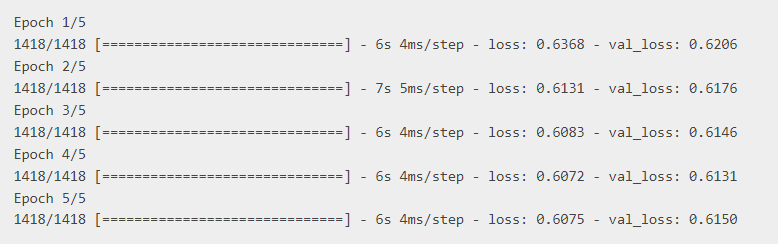

### Plot training and validation loss

In [ ]:
plt.plot(history.history["loss"])plt.plot(history.history["val_loss"])plt.title("model loss")plt.ylabel("loss")plt.xlabel("epoch")plt.legend(["train", "test"], loc="upper left")plt.show()

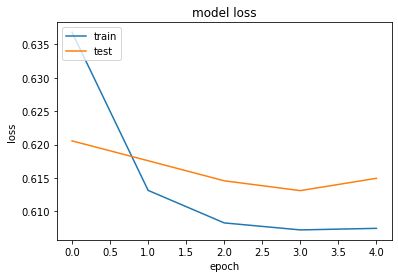

## Show top 10 movie recommendations to a user

In [ ]:
movie_df = pd.read_csv(movielens_dir / "movies.csv")# Let us get a user and see the top recommendations.user_id = df.userId.sample(1).iloc[0]movies_watched_by_user = df[df.userId == user_id]movies_not_watched = movie_df[    ~movie_df["movieId"].isin(movies_watched_by_user.movieId.values)]["movieId"]movies_not_watched = list(    set(movies_not_watched).intersection(set(movie2movie_encoded.keys())))movies_not_watched = [[movie2movie_encoded.get(x)] for x in movies_not_watched]user_encoder = user2user_encoded.get(user_id)user_movie_array = np.hstack(    ([[user_encoder]] * len(movies_not_watched), movies_not_watched))ratings = model.predict(user_movie_array).flatten()top_ratings_indices = ratings.argsort()[-10:][::-1]recommended_movie_ids = [    movie_encoded2movie.get(movies_not_watched[x][0]) for x in top_ratings_indices]print("Showing recommendations for user: {}".format(user_id))print("====" * 9)print("Movies with high ratings from user")print("----" * 8)top_movies_user = (    movies_watched_by_user.sort_values(by="rating", ascending=False)    .head(5)    .movieId.values)movie_df_rows = movie_df[movie_df["movieId"].isin(top_movies_user)]for row in movie_df_rows.itertuples():    print(row.title, ":", row.genres)print("----" * 8)print("Top 10 movie recommendations")print("----" * 8)recommended_movies = movie_df[movie_df["movieId"].isin(recommended_movie_ids)]for row in recommended_movies.itertuples():    print(row.title, ":", row.genres)

Showing recommendations for user: 474====================================Movies with high ratings from user--------------------------------Fugitive, The (1993) : ThrillerRemains of the Day, The (1993) : Drama|RomanceWest Side Story (1961) : Drama|Musical|RomanceX2: X-Men United (2003) : Action|Adventure|Sci-Fi|ThrillerSpider-Man 2 (2004) : Action|Adventure|Sci-Fi|IMAX--------------------------------Top 10 movie recommendations--------------------------------Dazed and Confused (1993) : ComedyGhost in the Shell (Kôkaku kidôtai) (1995) : Animation|Sci-FiDrugstore Cowboy (1989) : Crime|DramaRoad Warrior, The (Mad Max 2) (1981) : Action|Adventure|Sci-Fi|ThrillerDark Knight, The (2008) : Action|Crime|Drama|IMAXInglourious Basterds (2009) : Action|Drama|WarUp (2009) : Adventure|Animation|Children|DramaDark Knight Rises, The (2012) : Action|Adventure|Crime|IMAXStar Wars: Episode VII - The Force Awakens (2015) : Action|Adventure|Fantasy|Sci-Fi|IMAXThor: Ragnarok (2017) : Action|Adventure|Sci-Fi

#### Other Approach - Weighted AVG ApproachThe weighted avg of the ratings using cosine similarity as the weights. The users who are more similar to the input_user will have a higher weight in our rating computation for the input_user.#### Other Approach2 - Model-based approachesKNN and SVD. The surprise package has inbuilt libraries with different models to build recommender systems and we will use the same.In the KNN based approach, the prediction is done by finding a cluster of similar users to the input_user whose rating is to be predicted and then an average of those ratings is taken. KNN is a famous classification algorithm.In the SVD (Singular Value decomposition) method, the sparse user-movie ( ratings) matrix is compressed into a dense matrix by applying matrix factorization techniques. If M is a user* movie matrix, SVD decomposes it into 3 parts: M = UZV, where U is user concept matrix, Z is weights of different concepts and V is concept movie matrix. ‘Concept’ can be intuitively understood by imagining it as a superset of similar movies like a ‘suspense thriller’ genre can be a concept, etc.Once SVD decomposes the original matrix into 3, the dense matrix is directly used for predicting the rating for a (user, movie) pair using the concept to which the input_movie belongs.

## 7. Summary

Things to keep in mindWhile developing a recommendation system, especially for content based recommendation, it is important to remember NOT to optimize only for a single metric. That is to say, for news article recommendation, it is not advisable to get a very high recall, because this means that we are recommending the users the content they would have naturally consumed without our recommendation.Thus, we won’t be driving business in any way. We need to ensure a decent recall/precision as an indicator that our model is able to learn the users’ preferences, not try to make it as high as possible. Also, we don’t want to lose user engagement in the long run by recommending the same types of things over and over again. Thus is highly probable if we try to maximize precision or recall.

### What are today’s top recommendation engine algorithms?It keep changing and evolving rapidly and it's maybe your task to dig in :D

##  Applilcation of Surprise Module

## 1. Introduction

Surprise is a Python scikit for building and analyzing recommender systems that deal with explicit rating data.

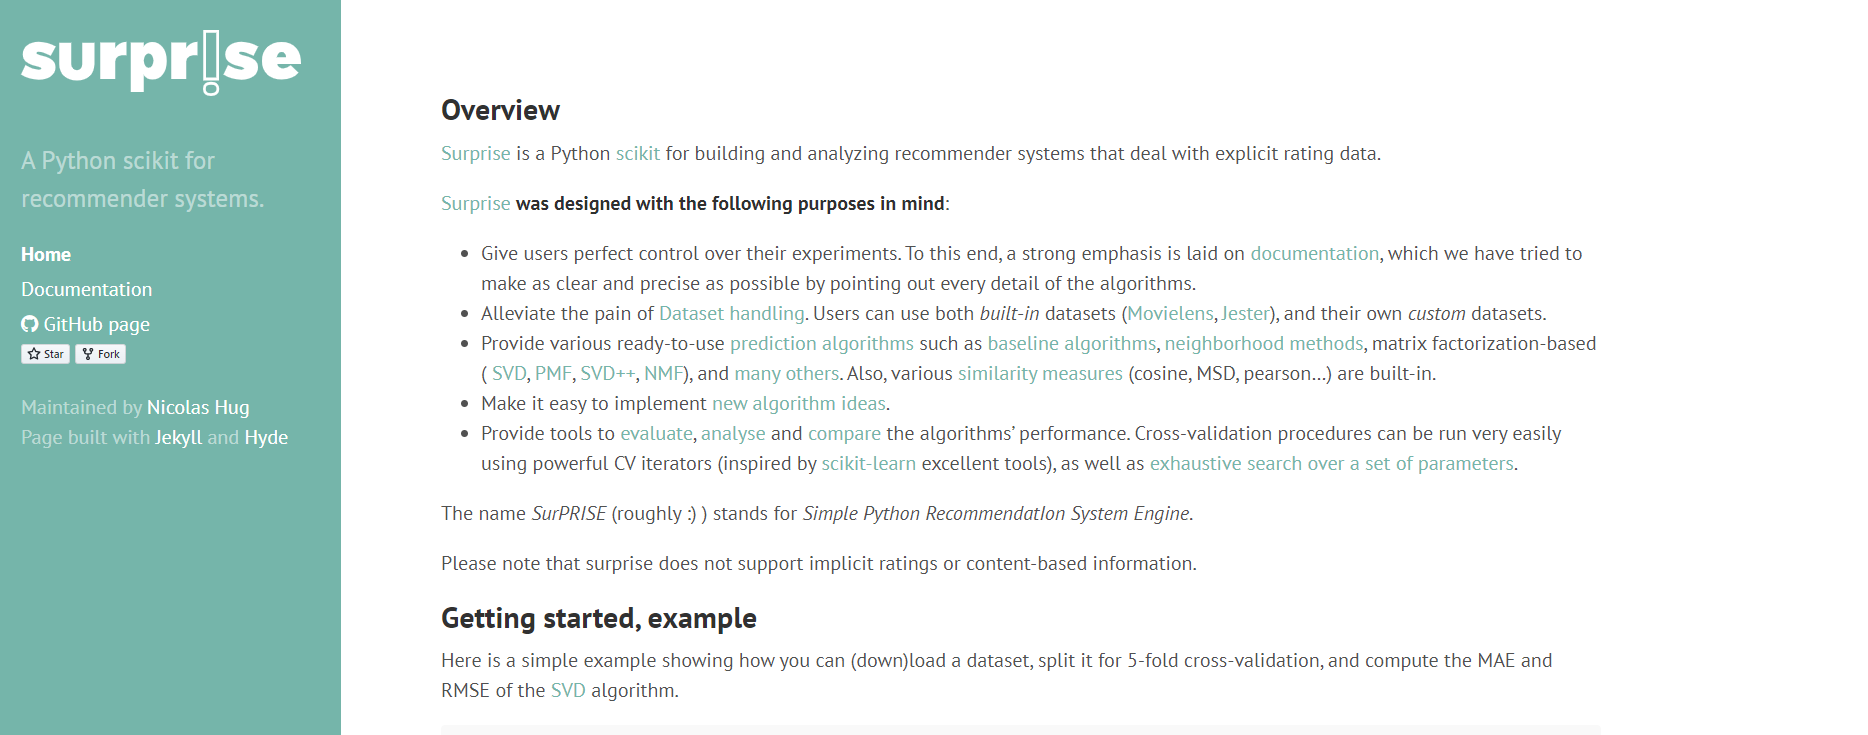

Surprise was designed with the following purposes in mind:1. Give users perfect control over their experiments2. Provide various ready-to-use prediction algorithms such as baseline algorithms, neighborhood methods3. Make it easy to implement new algorithm ideas.4. Provide tools to evaluate, analyze and compare the algorithms’ performance. Cross-validation procedures can be run very easily using  powerful CV iterators (inspired by sci-kit-learn excellent tools.

## 2. Installation

In [ ]:
pip install numpypip install scikit-surprise

Make sure that numpy module is installed before installation.

https://towardsdatascience.com/building-and-testing-recommender-systems-with-surprise-step-by-step-d4ba702ef80b

Data: http://www2.informatik.uni-freiburg.de/~cziegler/BX/

The Book-Crossing data comprises three tables, we will use two of them: The users table and the book ratings table.

In [ ]:
user = pd.read_csv('BX-Users.csv', sep=';', error_bad_lines=False, encoding="latin-1")user.columns = ['userID', 'Location', 'Age']rating = pd.read_csv('BX-Book-Ratings.csv', sep=';', error_bad_lines=False, encoding="latin-1")rating.columns = ['userID', 'ISBN', 'bookRating']df = pd.merge(user, rating, on='userID', how='inner')df.drop(['Location', 'Age'], axis=1, inplace=True)df.head()

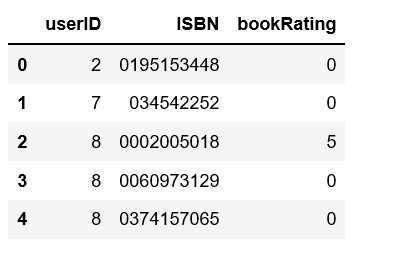

### EDA: Ratings Distribution

In [ ]:
from plotly.offline import init_notebook_mode, plot, iplotimport plotly.graph_objs as goinit_notebook_mode(connected=True)data = df['bookRating'].value_counts().sort_index(ascending=False)trace = go.Bar(x = data.index,               text = ['{:.1f} %'.format(val) for val in (data.values / df.shape[0] * 100)],               textposition = 'auto',               textfont = dict(color = '#000000'),               y = data.values,               )# Create layoutlayout = dict(title = 'Distribution Of {} book-ratings'.format(df.shape[0]),              xaxis = dict(title = 'Rating'),              yaxis = dict(title = 'Count'))# Create plotfig = go.Figure(data=[trace], layout=layout)iplot(fig)

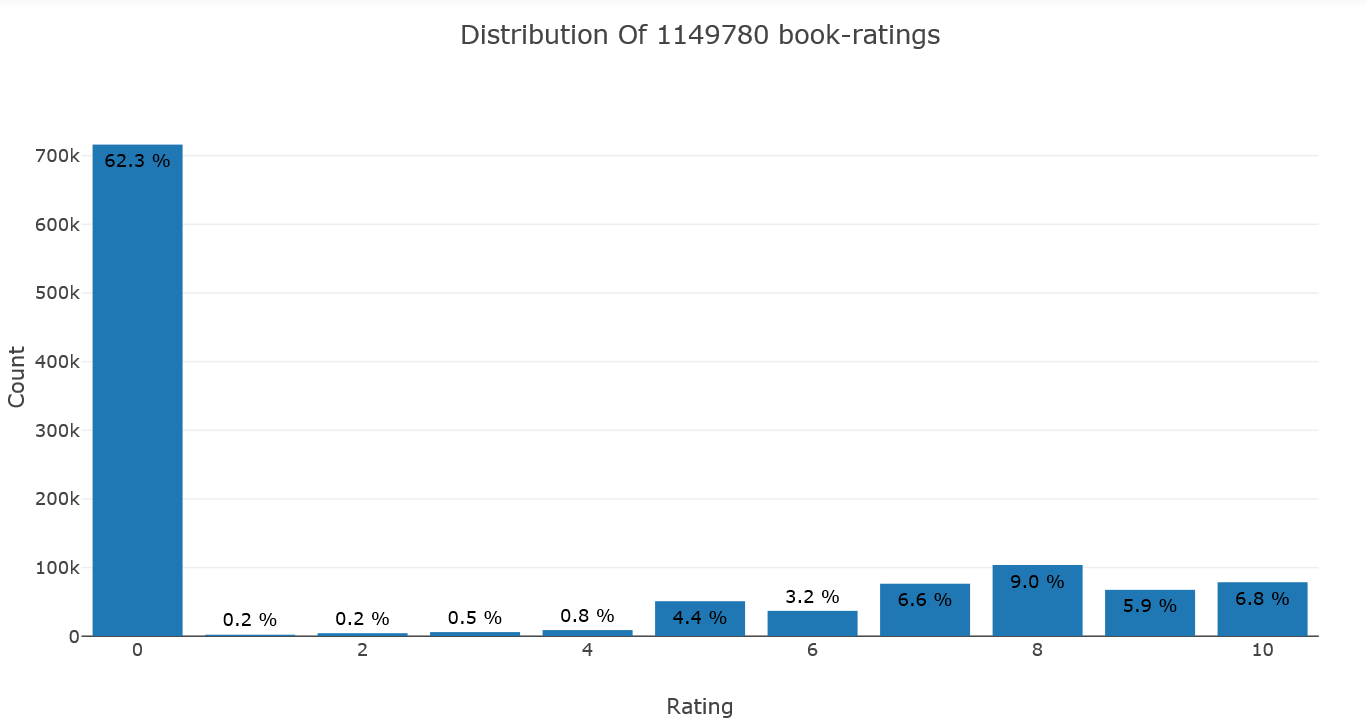

We can see that over 62% of all ratings in the data are 0, and very few ratings are 1 or 2, or 3, low rating books mean they are generally really bad.

### Ratings Distribution By Book

In [ ]:
# Number of ratings per bookdata = df.groupby('ISBN')['bookRating'].count().clip(upper=50)# Create tracetrace = go.Histogram(x = data.values,                     name = 'Ratings',                     xbins = dict(start = 0,                                  end = 50,                                  size = 2))# Create layoutlayout = go.Layout(title = 'Distribution Of Number of Ratings Per Book (Clipped at 100)',                   xaxis = dict(title = 'Number of Ratings Per Book'),                   yaxis = dict(title = 'Count'),                   bargap = 0.2)# Create plotfig = go.Figure(data=[trace], layout=layout)iplot(fig)

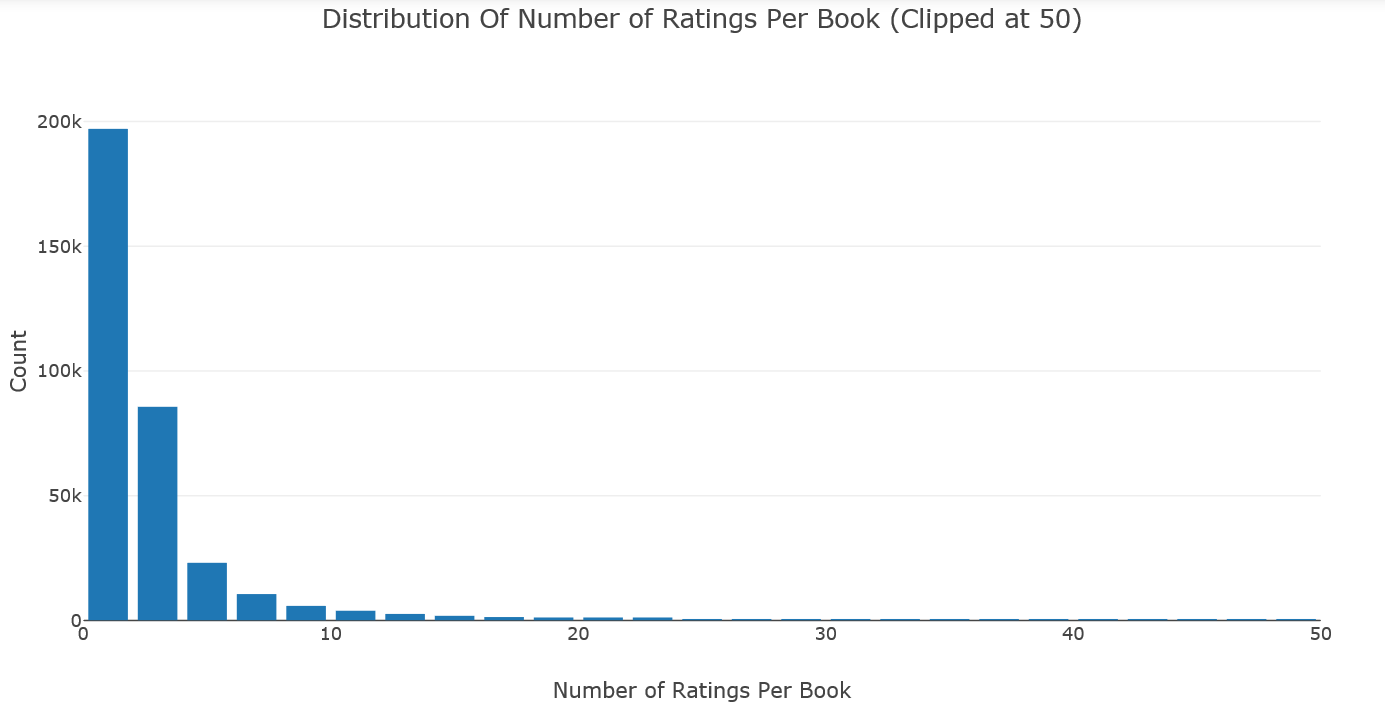

In [ ]:
df.groupby('ISBN')['bookRating'].count().reset_index().sort_values('bookRating', ascending=False)[:10]

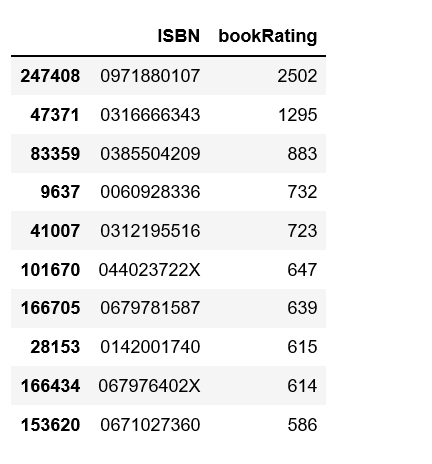

Most of the books in the data received less than 5 ratings, and very few books have many ratings, although the most rated book has received 2,502 ratings.

### Ratings Distribution By User

In [ ]:
# Number of ratings per userdata = df.groupby('userID')['bookRating'].count().clip(upper=50)# Create tracetrace = go.Histogram(x = data.values,                     name = 'Ratings',                     xbins = dict(start = 0,                                  end = 50,                                  size = 2))# Create layoutlayout = go.Layout(title = 'Distribution Of Number of Ratings Per User (Clipped at 50)',                   xaxis = dict(title = 'Ratings Per User'),                   yaxis = dict(title = 'Count'),                   bargap = 0.2)# Create plotfig = go.Figure(data=[trace], layout=layout)iplot(fig)

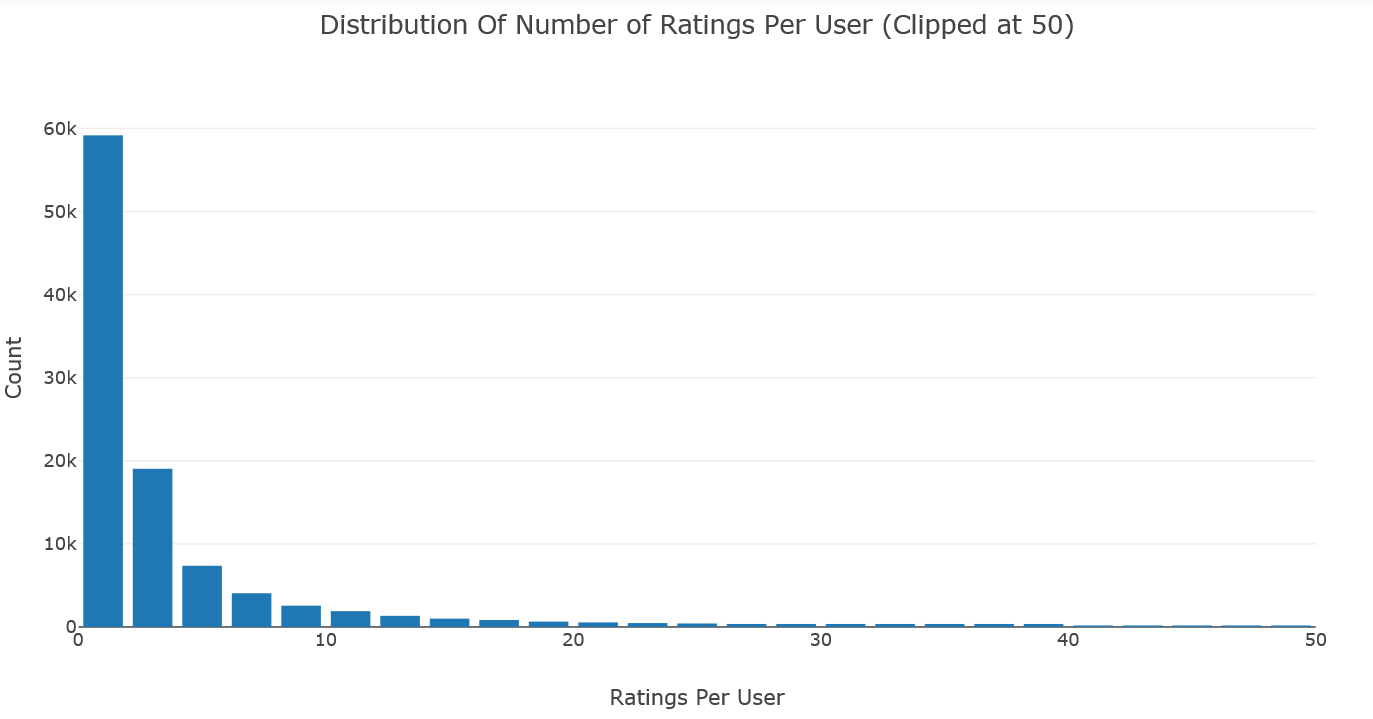

In [ ]:
df.groupby('userID')['bookRating'].count().reset_index().sort_values('bookRating', ascending=False)[:10]

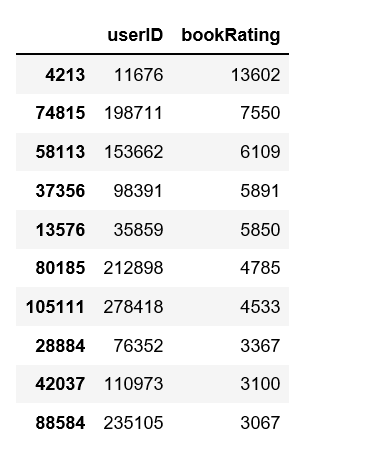

Most of the users in the data gave less than 5 ratings, and not many users gave many ratings, although the most productive user have given 13,602 ratings.I’m sure you have noticed that the above two plots share the same distribution. The number of ratings per book and the number of ratings per user decay exponentially.To reduce the dimensionality of the data set, and avoid running into “memory error”, we will filter out rarely rated books and rarely rating users.

In [ ]:
min_book_ratings = 50filter_books = df['ISBN'].value_counts() > min_book_ratingsfilter_books = filter_books[filter_books].index.tolist()min_user_ratings = 50filter_users = df['userID'].value_counts() > min_user_ratingsfilter_users = filter_users[filter_users].index.tolist()df_new = df[(df['ISBN'].isin(filter_books)) & (df['userID'].isin(filter_users))]print('The original data frame shape:\t{}'.format(df.shape))print('The new data frame shape:\t{}'.format(df_new.shape))

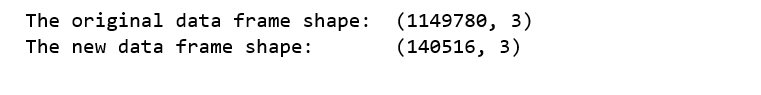

## 4. Now with Surprise

To load a data set from the above pandas data frame, we will use the load_from_df() method, we will also need a Reader object, and the rating_scale parameter must be specified. The data frame must have three columns, corresponding to the user ids, the item ids, and the ratings in this order. Each row thus corresponds to a given rating.

In [ ]:
reader = Reader(rating_scale=(0, 9))data = Dataset.load_from_df(df_new[['userID', 'ISBN', 'bookRating']], reader)

### With the Surprise library, we will benchmark the following algorithms:#### Basic algorithms: 
#### 1) Normal Predictor algorithm predicts a random rating based on the distribution of the training set, which is assumed to be normal. This is one of the most basic algorithms that do not do much work. 
#### 2) Baseline Only algorithm predicts the baseline estimate for given user and item.

#### k-NN algorithms 
#### 1) KNN Basic is a basic collaborative filtering algorithm. 
#### 2) KNN With Means is basic collaborative filtering algorithm, taking into account the mean ratings of each user. 
#### 3) KNN Baseline is a basic collaborative filtering algorithm taking into account a baseline rating.

#### Matrix Factorization-based algorithms:
#### 1) SVD algorithm is equivalent to Probabilistic Matrix Factorization. 
#### 2) The SVDpp algorithm is an extension of SVD that takes into account implicit ratings. 
#### 3) NMF is a collaborative filtering algorithm based on Non-negative Matrix Factorization. It is very similar with SVD.

#### Slope One  is a straight forward implementation of the SlopeOne algorithm. 
#### Co-clustering is a collaborative filtering algorithm based on co-clustering.

We use “rmse” as our accuracy metric for the predictions.

In [ ]:
benchmark = []# Iterate over all algorithmsfor algorithm in [SVD(), SVDpp(), SlopeOne(), NMF(), NormalPredictor(), KNNBaseline(), KNNBasic(), KNNWithMeans(), KNNWithZScore(), BaselineOnly(), CoClustering()]:    # Perform cross validation    results = cross_validate(algorithm, data, measures=['RMSE'], cv=3, verbose=False)        # Get results & append algorithm name    tmp = pd.DataFrame.from_dict(results).mean(axis=0)    tmp = tmp.append(pd.Series([str(algorithm).split(' ')[0].split('.')[-1]], index=['Algorithm']))    benchmark.append(tmp)    pd.DataFrame(benchmark).set_index('Algorithm').sort_values('test_rmse')    

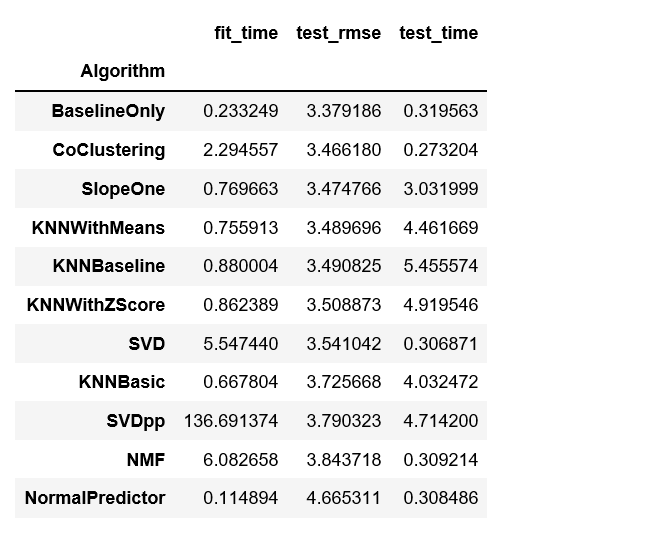

## 5. Train and Predict Baseline Only algorithm gave us the best rmse, therefore, we will train and predict with BaselineOnly and use Alternating Least Squares (ALS).

In [ ]:
print('Using ALS')bsl_options = {'method': 'als',               'n_epochs': 5,               'reg_u': 12,               'reg_i': 5               }algo = BaselineOnly(bsl_options=bsl_options)cross_validate(algo, data, measures=['RMSE'], cv=3, verbose=False)

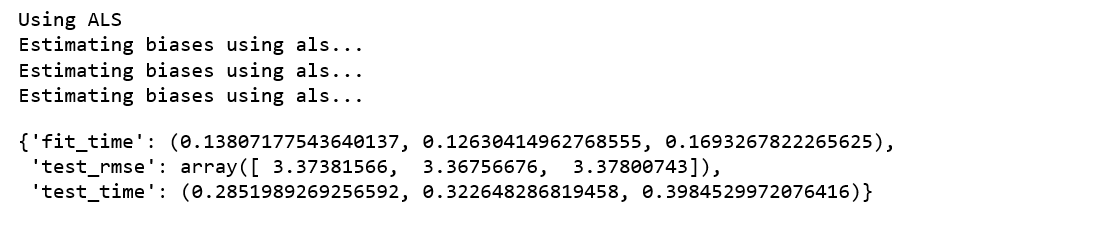

We use the train_test_split() to sample a trainset and a testset with given sizes, and use the accuracy metric of rmse. We’ll then use the fit() method which will train the algorithm on the trainset, and the test() method which will return the predictions made from the testset.

In [ ]:
trainset, testset = train_test_split(data, test_size=0.25)algo = BaselineOnly(bsl_options=bsl_options)predictions = algo.fit(trainset).test(testset)accuracy.rmse(predictions)

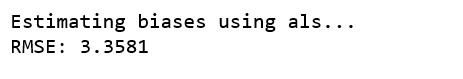

To inspect our predictions in details, we are going to build a pandas data frame with all the predictions. The following code were largely taken from this notebook.

In [ ]:
def get_Iu(uid):    """ return the number of items rated by given user    args:       uid: the id of the user    returns:       the number of items rated by the user    """    try:        return len(trainset.ur[trainset.to_inner_uid(uid)])    except ValueError: # user was not part of the trainset        return 0    def get_Ui(iid):    """ return number of users that have rated given item    args:      iid: the raw id of the item    returns:      the number of users that have rated the item.    """    try:         return len(trainset.ir[trainset.to_inner_iid(iid)])    except ValueError:        return 0    df = pd.DataFrame(predictions, columns=['uid', 'iid', 'rui', 'est', 'details'])df['Iu'] = df.uid.apply(get_Iu)df['Ui'] = df.iid.apply(get_Ui)df['err'] = abs(df.est - df.rui)best_predictions = df.sort_values(by='err')[:10]worst_predictions = df.sort_values(by='err')[-10:]

#### Best Predictions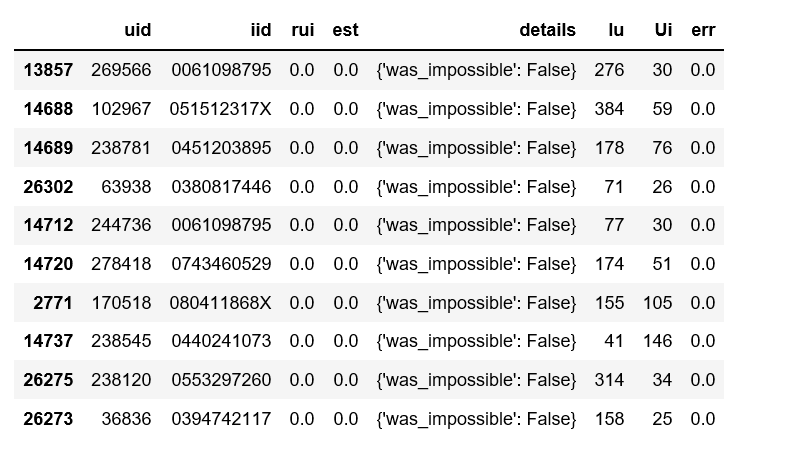

The above are the best predictions, and they are not lucky guesses. Because Ui is anywhere between 25 to 146, they are not really small, meaning that significant number of users have rated the target book.

#### Worst predictions:

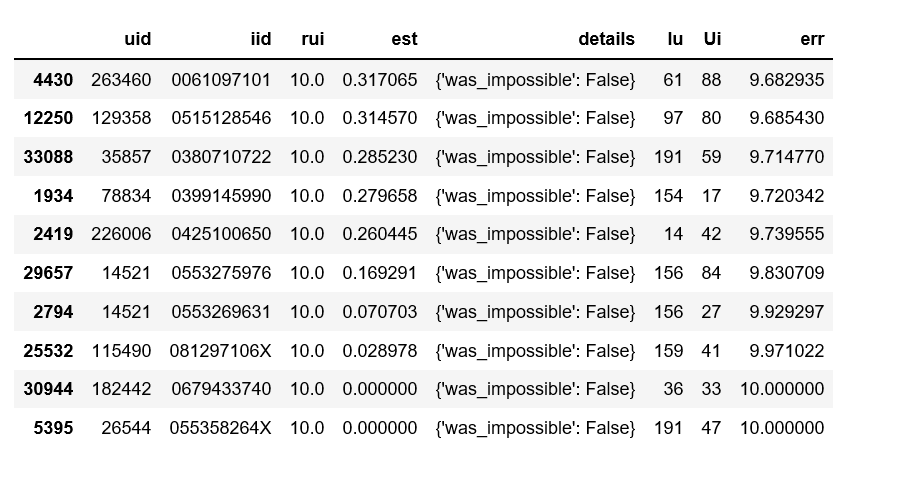

The worst predictions look pretty surprise. Let’s look in more details of the last one ISBN “055358264X”. The book was rated by 47 users, user “26544” rated 10, our BaselineOnly algorithm predicts this user would rate 0.

In [ ]:
import matplotlib.pyplot as plt%matplotlib notebookdf_new.loc[df_new['ISBN'] == '055358264X']['bookRating'].hist()plt.xlabel('rating')plt.ylabel('Number of ratings')plt.title('Number of ratings book ISBN 055358264X has received')plt.show();

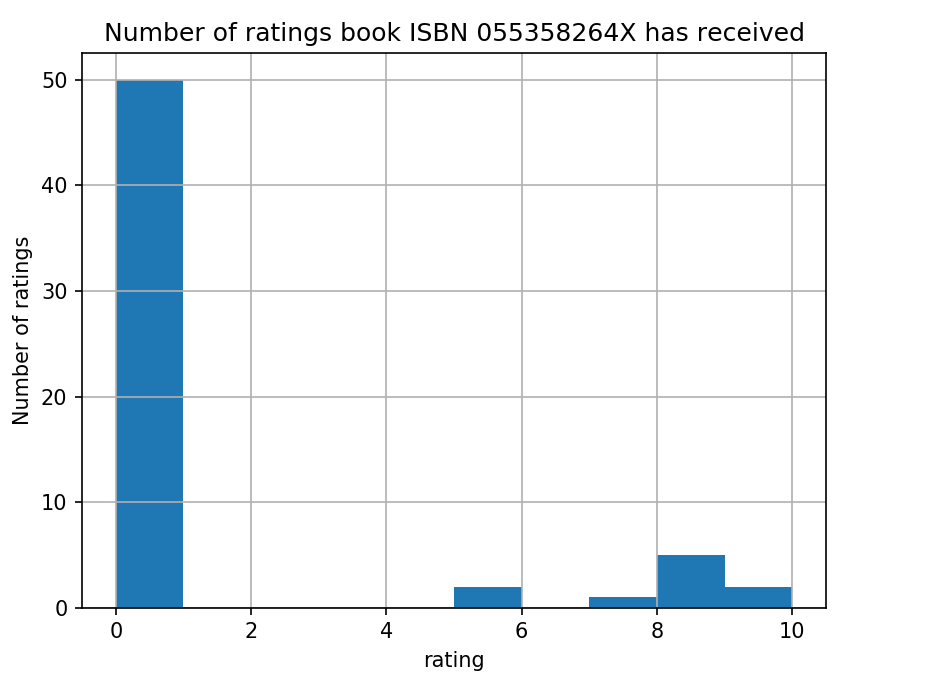

It turns out, most of the ratings this book received was 0, in another word, most of the users in the data rated this book 0, only very few users rated 10. Same with the other predictions in “worst predictions” list. It seems that for each prediction, the users are some kind of outsiders.That was it! I hope you enjoyed the recommendation (or rather, a rating prediction) journey with Surprise.

## 6. Why do we use Surprise? 
## Recommendation is emerging market for ML engineers and private enterprises actively use and develop them on their franchises. However, using existing libraries often overfits or requires significant training duration. To offset those limitations Surprise was suggested which is personalized module only used for building ML recommendation system. Surprise is both useful and simple because it can train a model that serves recommendations by using simple annotated data that includes fields for user ratings, item ratings, total user counts, item counts, ratings, and rating scale, all of which is required to build a simple recommender system.

## 7. Making personzlied movie Recommendation System https://towardsdatascience.com/make-your-own-book-and-movie-recommender-system-using-surprise-42cc1c840a19

Data: MovieLens / https://grouplens.org/datasets/movielens/latest/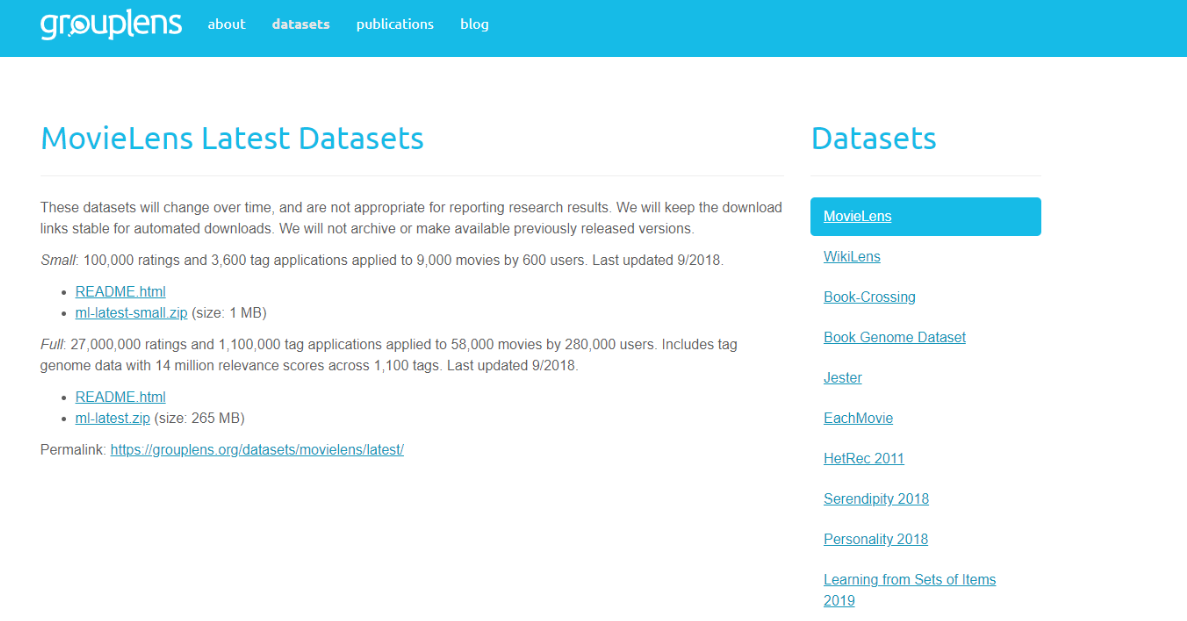

In [ ]:
RATINGS_DATA_FILE = './data/raw/ratings.csv'MOVIES_DATA_FILE = './data/raw/movies.csv'# load the raw csv into a data_framedf_ratings = pd.read_csv(RATINGS_DATA_FILE)# drop the timestamp column since we dont need it nowdf_ratings = df_ratings.drop(columns="timestamp")# movies dataframedf_movies = pd.read_csv(MOVIES_DATA_FILE)# check we have 25M users' ratingsdf_ratings.userId.count()

I use only a subset of this dataset for complexity matters but you can use it all. Then, I upload the ratings to a Surprise Dataset object which contains the following fields in this order:userIdmovieIdThe corresponding rating (usually on a scale such as 1–5)

In [ ]:
def get_subset(df, number):    """        just get a subset of a large dataset for debug purpose    """    rids = np.arange(df.shape[0])    np.random.shuffle(rids)    df_subset = df.iloc[rids[:number], :].copy()    return df_subsetdf_ratings_100k = get_subset(df_ratings, 100000)df_movies_100 = get_subset(df_movies, 100)# Surprise readerreader = Reader(rating_scale=(0, 5))# Finally load all ratingsratings = Dataset.load_from_df(df_ratings_100k, reader)

In [ ]:
# Training and Cross-Validating collaborative filtering modelskf = KFold(n_splits=3)algos = [SVD(), NMF(), KNNBasic()]    for trainset, testset in tqdm(kf.split(ratings)):     """        get an evaluation with cross-validation for different algorithms    """      for algo in algos:        algo.fit(trainset)        get_rmse(algo, testset)

0it [00:00, ?it/s]RMSE: 0.9265RMSE: 1.0959Computing the msd similarity matrix...Done computing similarity matrix.1it [00:12, 12.72s/it]RMSE: 0.9919RMSE: 0.9299RMSE: 1.1025Computing the msd similarity matrix...Done computing similarity matrix.2it [00:26, 13.54s/it]RMSE: 0.9915RMSE: 0.9270RMSE: 1.0996Computing the msd similarity matrix...Done computing similarity matrix.3it [00:42, 14.14s/it]RMSE: 0.9905

In [ ]:
## Training content-based filtering models# computing similarities requires too much ressources on the whole dataset, so we take the subset with 100 itemsdf_movies_100 = df_movies_100.reset_index(drop=True)df_movies_100.head(5)# we compute a TFIDF on the titles of the moviestf = TfidfVectorizer(analyzer='word', ngram_range=(1, 3), min_df=0, stop_words='english')tfidf_matrix = tf.fit_transform(df_movies_100['title'])# we get cosine similarities: this takes a lot of time on the real datasetcosine_similarities = linear_kernel(tfidf_matrix, tfidf_matrix)# we generate in 'results' the most similar movies for each movie: we put a pair (score, movie_id)results = {}for idx, row in df_movies_100.iterrows():    similar_indices = cosine_similarities[idx].argsort()[:-100:-1]     similar_items = [(cosine_similarities[idx][i], df_movies_100['movieId'].loc[[i]].tolist()[0]) for i in similar_indices]     results[idx] = similar_items[1:]

Suppose a user wants the 10 most ‘similar’ movies from the movie ‘Scientology and the Prison of Belief (2015)’.

In [ ]:
recommend(item_id=157679, num=10)

In [ ]:
Recommending 10 products similar to Going Clear: Scientology and the Prison of Belief (2015)...-------	Recommended: Soulless 2 (2015) (score:0.09111541613391295)	Recommended: Víkend (2015) (score:0.09111541613391295)	Recommended: No Longer Heroine (2015) (score:0.06179864475000222)	Recommended: In the Shadow of Women (2015) (score:0.06179864475000222)	Recommended: Marco Polo: One Hundred Eyes (2015) (score:0.05026525144746273)	Recommended: Ugly American, The (1963) (score:0.0)	Recommended: Snitch Cartel, The (El cartel de los sapos) (2011) (score:0.0)	Recommended: Drone (2014) (score:0.0)	Recommended: Kenny Rogers as The Gambler (1980) (score:0.0)	Recommended: Le Rossignol (2005) (score:0.0)

That’s it! You can apply this recommender system code template to any data you want.

## 8. Other Open Source Packages for Recommendation Systems

#### LensKit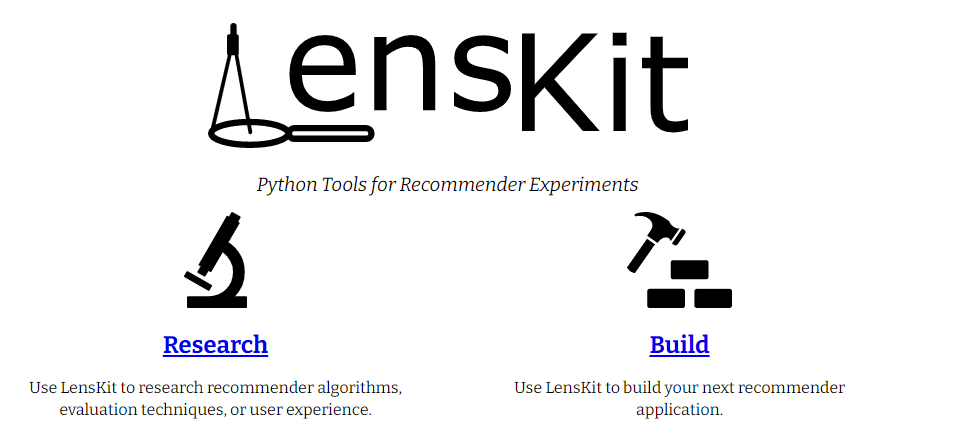LensKit is a free and open-source framework for developing, investigating, and learning about recommender systems. It supports developing, running, and assessing recommender algorithms in a flexible manner appropriate for research and education. LensKit for Python (LKPY) is the Python-based successor of the Java-based LensKit toolkit and a component of the LensKit project. LKPY allows creating robust, adaptable, and reproducible experiments that leverage the broad and developing PyData and Scientific Python ecosystems, such as scikit-learn and TensorFlow.#### GrabCrab is a Python recommender engine that combines classic information filtering recommendation methods into a variety of scientific Python libraries, including Numpy, Scipy, and Matplotlib. It’s also known as Scikits recommender, and it seeks to give a comprehensive set of components from which one may build a personalised recommender system from a set of algorithms that can be utilized in a variety of situations. User-based filtering, item-based filtering, and other capabilities are available in Crab.#### TensorRec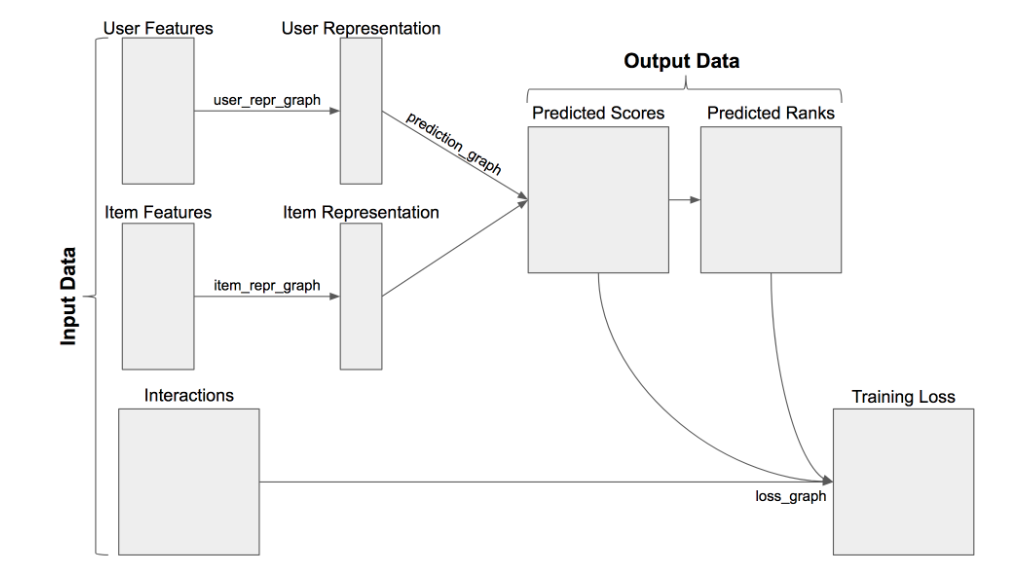TensorRec is a Python recommendation system that lets you quickly create and customize recommendation systems using TensorFlow. User features, item features, and interactions are the three types of data that a TensorRec system consumes. It learns to produce and rank recommendations using this data. TensorRec learns by comparing the scores it generates to real-world interactions between users and items, such as likes and dislikes.

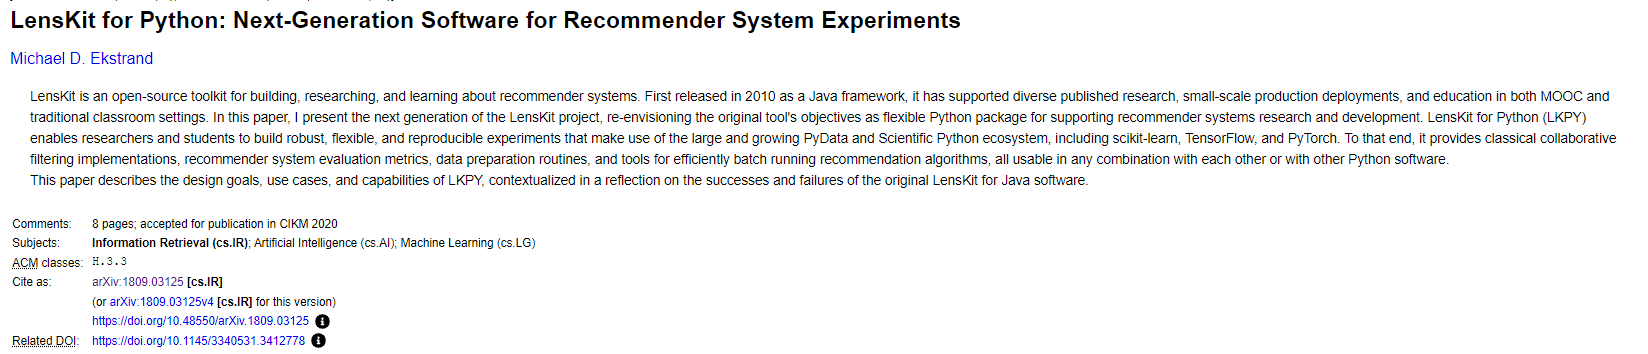

### Basic Use of Tensorrec

In [ ]:
import numpy as npimport tensorrec# Build the model with default parametersmodel = tensorrec.TensorRec()# Generate some dummy datainteractions, user_features, item_features = tensorrec.util.generate_dummy_data(    num_users=100,    num_items=150,    interaction_density=.05)# Fit the model for 5 epochsmodel.fit(interactions, user_features, item_features, epochs=5, verbose=True)# Predict scores and ranks for all users and all itemspredictions = model.predict(user_features=user_features,                            item_features=item_features)predicted_ranks = model.predict_rank(user_features=user_features,                                     item_features=item_features)# Calculate and print the recall at 10r_at_k = tensorrec.eval.recall_at_k(predicted_ranks, interactions, k=10)print(np.mean(r_at_k))

## 9. Authentic Applications

#### Session-Based Recommender System The interactions of a user during a session are used to produce recommendations in these recommender systems. Youtube and Amazon both utilize session-based recommender systems. When a user’s history (such as previous clicks or transactions) is not available or relevant in the current user session, they are particularly valuable. Video, e-commerce, travel, music, and other domains are all examples of when session-based suggestions are useful. Most session-based recommender systems rely on the sequence of recent interactions inside a session without requiring any further information about the user (history, demographics).#### Multi-Criteria Recommender System Multi-criteria recommender systems (MCRS) are recommender systems that take into account many factors when making recommendations. Rather than developing recommendation techniques based on a single criterion value, such as user u’s overall preference for an item I, these systems attempt to predict a rating for unexplored items of u by leveraging preference information on multiple criteria that influence this overall preference value. Several researchers see MCRS as a multi-criteria decision-making (MCDM) problem and construct MCRS systems using MCDM approaches and techniques.

### Bonus + Dating App? (Hinge)https://medium.com/swlh/dating-data-an-overview-of-the-algorithm-afb9f0c08e2c#### Option 1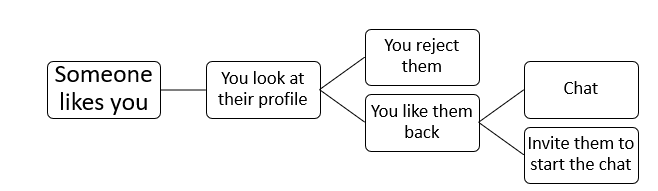#### Option 2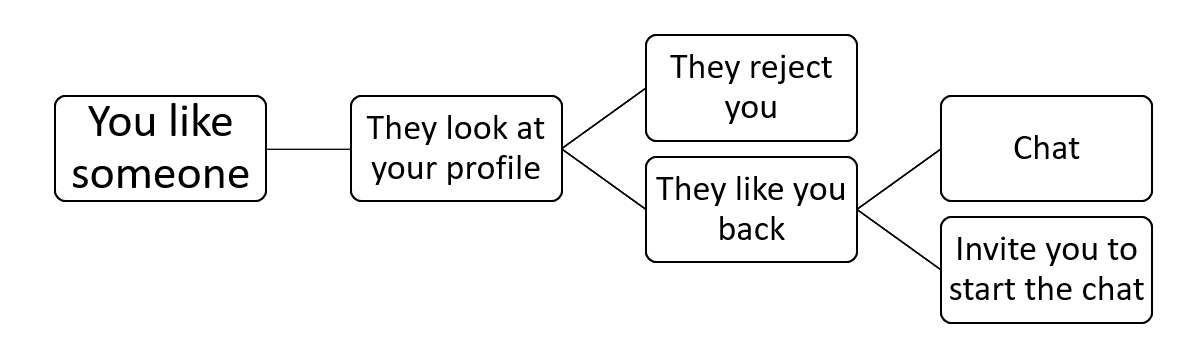#### The Gale-Shapley AlgorithmHinge uses the Gale-Shapley algorithm that pairs people “who are likely to mutually like one another”. It measures this based off your engagement and who engages with you, as well as matches you to people with similar preferences.The Gale-Shapley algorithm solves this through a series of iterations in which Element A proposes to their highest ranked Element B. Element B responds yes or no — if no, Element A then goes to propose to their next most-preferred Element B until everyone is engaged. The matching is considered stable when there is no match (A, B) that prefer each other over their current partners.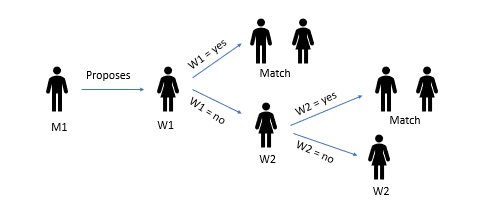